<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Sesiones/Sesion07_bDatos_Ising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Modelo de Ising 2D: generación de datos para clasificación con redes neuronales

Construiremos el proyecto por partes:

1. **Geometría de la red** (esta sección): red cuadrada $L\times L$ parametrizable, con condiciones de frontera periódicas o libres, y visualización.
2. Asignación de espines aleatorios ($s_i = \pm 1$) sobre la red.
3. Dinámica de Monte Carlo (algoritmo de Metropolis) para muestrear el equilibrio térmico.
4. Cálculo de observables por sitio en función de la temperatura: magnetización, susceptibilidad y calor específico.
5. Generación del dataset (configuraciones de espines etiquetadas por fase/temperatura) para entrenar una red neuronal clasificadora.

## 1. Geometría de la red

Definimos una red cuadrada de $L \times L$ sitios. Cada sitio $s$ tiene coordenadas $(i, j)$ con $i, j \in \{0, \dots, L-1\}$, e índice lineal $s = i \cdot L + j$.

La conectividad (vecinos más cercanos: arriba, abajo, izquierda, derecha) depende de la **condición de frontera**:

- **Periódica**: la red se enrolla sobre sí misma (topología de toro). El sitio en el borde derecho es vecino del sitio en el borde izquierdo de la misma fila, y análogamente para arriba/abajo. Todos los sitios tienen exactamente 4 vecinos.
- **Libre** (abierta): no hay conexión entre bordes opuestos. Los sitios de esquina tienen 2 vecinos, los de borde 3, y los interiores 4.

La clase `RedIsing2D` construye esta geometría de forma parametrizable en `L` y `frontera`, y permite visualizarla.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class RedIsing2D:
    """
    Geometria de una red cuadrada LxL para el modelo de Ising.

    Parametros
    ----------
    L : int
        Tamano lineal de la red (numero de sitios por lado). Se recomienda L >= 3.
    frontera : str
        Condicion de frontera: 'periodica' o 'libre'.
    """

    def __init__(self, L, frontera='periodica'):
        if frontera not in ('periodica', 'libre'):
            raise ValueError("frontera debe ser 'periodica' o 'libre'")
        self.L = L
        self.N = L * L
        self.frontera = frontera
        self.vecinos, self._direcciones = self._construir_vecinos()

    def indice(self, i, j):
        """Coordenadas (fila, columna) -> indice lineal 0..N-1."""
        return i * self.L + j

    def coordenadas(self, s):
        """Indice lineal -> coordenadas (fila, columna)."""
        return divmod(s, self.L)

    def _construir_vecinos(self):
        L = self.L
        vecinos = {}
        direcciones = {}
        for i in range(L):
            for j in range(L):
                s = self.indice(i, j)
                if self.frontera == 'periodica':
                    d = {
                        'arriba': self.indice((i - 1) % L, j),
                        'abajo': self.indice((i + 1) % L, j),
                        'izquierda': self.indice(i, (j - 1) % L),
                        'derecha': self.indice(i, (j + 1) % L),
                    }
                else:  # libre
                    d = {
                        'arriba': self.indice(i - 1, j) if i - 1 >= 0 else None,
                        'abajo': self.indice(i + 1, j) if i + 1 < L else None,
                        'izquierda': self.indice(i, j - 1) if j - 1 >= 0 else None,
                        'derecha': self.indice(i, j + 1) if j + 1 < L else None,
                    }
                direcciones[s] = d
                vecinos[s] = [v for v in d.values() if v is not None]
        return vecinos, direcciones

    def vecinos_de(self, s):
        """Devuelve el diccionario de vecinos por direccion (arriba/abajo/izquierda/derecha) del sitio s."""
        return self._direcciones[s]

    def tabla_vecinos(self):
        """Tabla completa de vecinos: un DataFrame con una fila por sitio y sus vecinos por direccion.

        Permite consultar un sitio puntual con, por ejemplo, `tabla.loc[10]`.
        """
        import pandas as pd
        filas = []
        for s in range(self.N):
            i, j = self.coordenadas(s)
            d = self._direcciones[s]
            filas.append({
                'sitio': s,
                'fila': i,
                'columna': j,
                'arriba': d['arriba'],
                'abajo': d['abajo'],
                'izquierda': d['izquierda'],
                'derecha': d['derecha'],
                'num_vecinos': len(self.vecinos[s]),
            })
        return pd.DataFrame(filas).set_index('sitio')

    def graficar(self, mostrar_indices=False, figsize=(5, 5), ax=None):
        """Dibuja los sitios de la red y los enlaces a primeros vecinos.

        Los enlaces que cruzan la frontera periodica (toro) se dibujan
        punteados y en otro color para distinguirlos de los enlaces normales.
        """
        L = self.L
        creado = False
        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            creado = True

        enlaces_normales = set()
        enlaces_frontera = set()
        for s, vecs in self.vecinos.items():
            i, j = self.coordenadas(s)
            for v in vecs:
                vi, vj = self.coordenadas(v)
                enlace = frozenset((s, v))
                if abs(vi - i) > 1 or abs(vj - j) > 1:
                    enlaces_frontera.add(enlace)
                else:
                    enlaces_normales.add(enlace)

        for enlace in enlaces_normales:
            s, v = tuple(enlace)
            i, j = self.coordenadas(s)
            vi, vj = self.coordenadas(v)
            ax.plot([j, vj], [i, vi], '-', color='tab:blue', lw=1, alpha=0.7, zorder=1)

        for enlace in enlaces_frontera:
            s, v = tuple(enlace)
            i, j = self.coordenadas(s)
            vi, vj = self.coordenadas(v)
            ax.plot([j, vj], [i, vi], '--', color='tab:orange', lw=1, alpha=0.5, zorder=1)

        xs = [self.coordenadas(s)[1] for s in range(self.N)]
        ys = [self.coordenadas(s)[0] for s in range(self.N)]
        ax.scatter(xs, ys, color='black', s=60, zorder=2)

        if mostrar_indices:
            for s in range(self.N):
                i, j = self.coordenadas(s)
                ax.annotate(str(s), (j, i), textcoords='offset points', xytext=(5, 5), fontsize=8)

        ax.set_title(f'Red {L}x{L} — frontera {self.frontera}')
        ax.set_aspect('equal')
        ax.invert_yaxis()
        ax.set_xticks(range(L))
        ax.set_yticks(range(L))

        if creado:
            plt.show()
        return ax

### Verificación: frontera periódica para diferentes tamaños

Para condiciones de frontera periódicas, cada sitio de la red debe tener
exactamente **4 primeros vecinos**, independientemente del tamaño del sistema.

Verificaremos esta propiedad para

$$
L=10,\;15,\;20,\;25,\;30.
$$

En todos los casos debe cumplirse

$$
N_{\mathrm{vecinos}}(s)=4
$$

para cada sitio $s$ de la red.

In [4]:
# Tamaños de red que utilizaremos en el reto
tamanos = [10, 15, 20, 25, 30]

print("Verificación de las redes con frontera periódica\n")

for L in tamanos:

    red_periodica = RedIsing2D(
        L=L,
        frontera="periodica"
    )

    num_vecinos = set(
        len(v) for v in red_periodica.vecinos.values()
    )

    print(f"Red {L}x{L}")
    print(f"  Número de sitios: {red_periodica.N}")
    print(f"  Vecinos del sitio 0: {red_periodica.vecinos[0]}")
    print(f"  Número de vecinos por sitio: {num_vecinos}")
    print("-" * 45)

Verificación de las redes con frontera periódica

Red 10x10
  Número de sitios: 100
  Vecinos del sitio 0: [90, 10, 9, 1]
  Número de vecinos por sitio: {4}
---------------------------------------------
Red 15x15
  Número de sitios: 225
  Vecinos del sitio 0: [210, 15, 14, 1]
  Número de vecinos por sitio: {4}
---------------------------------------------
Red 20x20
  Número de sitios: 400
  Vecinos del sitio 0: [380, 20, 19, 1]
  Número de vecinos por sitio: {4}
---------------------------------------------
Red 25x25
  Número de sitios: 625
  Vecinos del sitio 0: [600, 25, 24, 1]
  Número de vecinos por sitio: {4}
---------------------------------------------
Red 30x30
  Número de sitios: 900
  Vecinos del sitio 0: [870, 30, 29, 1]
  Número de vecinos por sitio: {4}
---------------------------------------------


Para consultar los vecinos de un sitio puntual (por ejemplo el sitio 10) de forma clara, o inspeccionar la conectividad completa, usamos `tabla_vecinos()`, que devuelve un `DataFrame` indexado por sitio.

In [5]:
# Ejemplo: tabla de vecinos para la red L = 10

red_ejemplo = RedIsing2D(L=10, frontera="periodica")

tabla_periodica = red_ejemplo.tabla_vecinos()

tabla_periodica

,fila,columna,arriba,abajo,izquierda,derecha,num_vecinos
sitio,,,,,,,
0,0,0,90,10,9,1,4
1,0,1,91,11,0,2,4
2,0,2,92,12,1,3,4
3,0,3,93,13,2,4,4
4,0,4,94,14,3,5,4
...,...,...,...,...,...,...,...
95,9,5,85,5,94,96,4
96,9,6,86,6,95,97,4
97,9,7,87,7,96,98,4


In [6]:
# Consultar un sitio puntual, p. ej. el sitio 10
tabla_periodica.loc[10]

,10
fila,1
columna,0
arriba,0
abajo,20
izquierda,19
derecha,11
num_vecinos,4


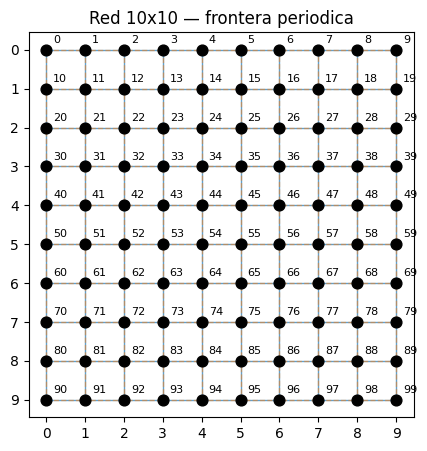

<Axes: title={'center': 'Red 10x10 — frontera periodica'}>

In [7]:
# Visualización de la red L = 10 con frontera periódica
red_ejemplo.graficar(mostrar_indices=True)

### Verificación: frontera libre

Como comprobación adicional de la geometría, analizamos una red con condición
de frontera libre.

En este caso, el número de primeros vecinos depende de la posición del sitio:

- **Esquinas:** 2 vecinos.
- **Bordes:** 3 vecinos.
- **Interior:** 4 vecinos.

Por tanto, para una red con frontera libre deben aparecer los tres valores:

$$
N_{\mathrm{vecinos}}\in\{2,3,4\}.
$$

Esta verificación se realiza únicamente para comprobar el funcionamiento de
la clase `RedIsing2D`. Para la generación de los datasets del reto se
utilizarán condiciones de frontera **periódicas** para todos los tamaños

$$
L=10,\;15,\;20,\;25,\;30.
$$

In [8]:
# Verificación de frontera libre usando una red L = 10

red_libre = RedIsing2D(L=10, frontera="libre")

print(f"Número de sitios: {red_libre.N}")

print(
    f"Vecinos del sitio 0 (esquina superior izquierda): "
    f"{red_libre.vecinos[0]}"
)

print(
    "Número de vecinos por sitio "
    "(debe variar entre 2, 3 y 4):",
    sorted(set(len(v) for v in red_libre.vecinos.values()))
)

Número de sitios: 100
Vecinos del sitio 0 (esquina superior izquierda): [10, 1]
Número de vecinos por sitio (debe variar entre 2, 3 y 4): [2, 3, 4]


In [9]:
# En frontera libre, un sitio de borde/esquina tiene NaN
# en la(s) dirección(es) donde no existe vecino

tabla_libre = red_libre.tabla_vecinos()

# El sitio 10 corresponde a (fila=1, columna=0), es decir, al borde izquierdo
tabla_libre.loc[10]

,10
fila,1.0
columna,0.0
arriba,0.0
abajo,20.0
izquierda,NaN
derecha,11.0
num_vecinos,3.0


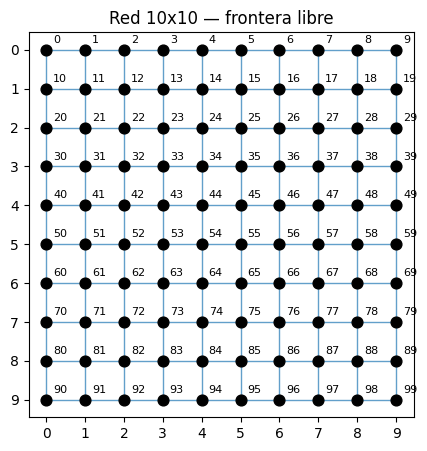

<Axes: title={'center': 'Red 10x10 — frontera libre'}>

In [10]:
# Visualización de la red L = 10 con frontera libre
red_libre.graficar(mostrar_indices=True)

Con la geometría lista (red parametrizable en `L` y en tipo de frontera, con visualización), el siguiente paso es **asignar espines aleatorios** $s_i \in \{-1, +1\}$ a cada sitio de la red.

Con la geometría lista —parametrizable tanto en el tamaño $L$ como en el
tipo de frontera—, el siguiente paso es asignar espines
$s_i\in\{-1,+1\}$ a cada sitio de la red.

---

## 2. Asignación de espines aleatorios

A cada sitio $s$ de una red $L\times L$ se le asigna un espín

$$
s_i\in\{-1,+1\},
$$

donde $+1$ representa un espín "arriba" ($\uparrow$) y $-1$ un espín
"abajo" ($\downarrow$).

En una configuración aleatoria, cada sitio se genera de manera independiente:

$$
P(s_i=+1)=p,
\qquad
P(s_i=-1)=1-p.
$$

Por defecto utilizaremos

$$
p=\frac{1}{2},
$$

por lo que no existe preferencia inicial por ninguna de las dos orientaciones.
Esta configuración corresponde a un estado inicialmente desordenado y será
utilizada como punto de partida para la dinámica de Monte Carlo.

Para una red de tamaño $L$, la configuración se almacena como un vector

$$
\mathbf{s}=(s_1,s_2,\ldots,s_N),
\qquad N=L^2,
$$

que puede reorganizarse como una matriz $L\times L$ mediante

`espines.reshape(L, L)`.

En este reto trabajaremos con

$$
L=10,\;15,\;20,\;25,\;30,
$$

por lo que las configuraciones contendrán respectivamente

$$
N=100,\;225,\;400,\;625,\;900
$$

espines.

Un observable útil para caracterizar cada configuración es la
**magnetización por sitio**,

$$
m=\frac{1}{N}\sum_{i=1}^{N}s_i,
\qquad -1\leq m\leq1.
$$

Para una configuración aleatoria sin sesgo y un número suficientemente grande
de espines se espera, en promedio,

$$
\langle m\rangle \approx 0.
$$

Sin embargo, una configuración individual finita no tiene por qué presentar
exactamente $m=0$, debido a las fluctuaciones estadísticas.

Estas configuraciones aleatorias se utilizarán posteriormente como
condiciones iniciales de la dinámica de Monte Carlo mediante el algoritmo
de Metropolis.

In [11]:
def asignar_espines_aleatorios(red, p_arriba=0.5, semilla=None):
    """
    Asigna a cada sitio de la red un espin aleatorio s_i en {-1, +1}.

    Cada sitio se decide de forma independiente: +1 ("arriba") con probabilidad
    p_arriba y -1 ("abajo") con probabilidad 1 - p_arriba.

    Parametros
    ----------
    red : RedIsing2D
        Geometria de la red (aporta el numero de sitios N).
    p_arriba : float
        Probabilidad de espin +1. Por defecto 0.5 (sin sesgo).
    semilla : int o None
        Semilla del generador aleatorio, para reproducibilidad.

    Devuelve
    --------
    espines : np.ndarray, forma (N,), dtype int8, valores en {-1, +1}
        Vector de espines indexado por el indice lineal del sitio (s = i*L + j).
    """
    rng = np.random.default_rng(semilla)
    espines = np.where(rng.random(red.N) < p_arriba, 1, -1).astype(np.int8)
    return espines


def magnetizacion_por_sitio(espines):
    """Magnetizacion por sitio: m = (1/N) sum_i s_i, en el rango [-1, 1]."""
    return float(np.mean(espines))

In [12]:
# Tamaños de red para el reto de escalamiento
tamanos = [10, 15, 20, 25, 30]

for L in tamanos:

    red = RedIsing2D(L=L, frontera="periodica")

    espines = asignar_espines_aleatorios(
        red,
        p_arriba=0.5,
        semilla=42
    )

    n_arriba = int((espines == 1).sum())
    n_abajo = int((espines == -1).sum())

    print(f"Red: {red.L}x{red.L} = {red.N} sitios, frontera {red.frontera}")
    print(f"Espín +1 (arriba): {n_arriba} sitios")
    print(f"Espín -1 (abajo) : {n_abajo} sitios")
    print(
        f"Magnetización por sitio m = "
        f"{magnetizacion_por_sitio(espines):+.4f}"
    )
    print("-" * 55)

Red: 10x10 = 100 sitios, frontera periodica
Espín +1 (arriba): 53 sitios
Espín -1 (abajo) : 47 sitios
Magnetización por sitio m = +0.0600
-------------------------------------------------------
Red: 15x15 = 225 sitios, frontera periodica
Espín +1 (arriba): 116 sitios
Espín -1 (abajo) : 109 sitios
Magnetización por sitio m = +0.0311
-------------------------------------------------------
Red: 20x20 = 400 sitios, frontera periodica
Espín +1 (arriba): 202 sitios
Espín -1 (abajo) : 198 sitios
Magnetización por sitio m = +0.0100
-------------------------------------------------------
Red: 25x25 = 625 sitios, frontera periodica
Espín +1 (arriba): 309 sitios
Espín -1 (abajo) : 316 sitios
Magnetización por sitio m = -0.0112
-------------------------------------------------------
Red: 30x30 = 900 sitios, frontera periodica
Espín +1 (arriba): 450 sitios
Espín -1 (abajo) : 450 sitios
Magnetización por sitio m = +0.0000
-------------------------------------------------------


### Visualización de las configuraciones

Podemos representar una configuración de espines de dos formas:

1. **Red + espín:** cada sitio de la red se representa mediante un punto
   asociado a su espín, indicando $\uparrow$ para $s_i=+1$ y
   $\downarrow$ para $s_i=-1$. Esta representación permite observar
   simultáneamente la geometría de la red y la orientación de cada espín,
   por lo que resulta especialmente útil para redes pequeñas.

2. **Blanco y negro:** la configuración se reorganiza como una matriz
   $L\times L$ y se representa como una imagen, utilizando blanco para

   $$
   s_i=+1
   $$

   y negro para

   $$
   s_i=-1.
   $$

   Esta es una representación habitual de las configuraciones del modelo de
   Ising y resulta especialmente conveniente cuando aumenta el tamaño de la
   red.

En este reto se trabajará con

$$
L=10,\;15,\;20,\;25,\;30.
$$

Para tamaños pequeños puede utilizarse la representación detallada de
**red + espín**, mientras que para redes grandes será más conveniente la
representación matricial en blanco y negro.

En una configuración inicialmente aleatoria con $p=0.5$ no esperamos
correlaciones espaciales apreciables, por lo que la imagen presenta una
apariencia similar a ruido aleatorio. Después de la termalización mediante
Monte Carlo, especialmente para temperaturas por debajo de la transición,
comenzarán a observarse regiones o dominios de espines con la misma
orientación.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

COLOR_ARRIBA = '#D55E00'
COLOR_ABAJO  = '#0072B2'


def graficar_configuracion(
    red,
    espines,
    con_enlaces=True,
    con_flechas=True,
    tam_flecha=0.55,
    ancho_flecha=0.018,
    tam_cabeza=4.5,
    figsize=(4, 4),
    ax=None
):

    L = red.L

    creado = ax is None

    if creado:
        fig, ax = plt.subplots(figsize=figsize)

    # Coordenadas
    ij = np.array(
        [red.coordenadas(s) for s in range(red.N)],
        dtype=float
    )

    yi = ij[:, 0]
    xj = ij[:, 1]

    # --------------------------------------------------
    # Enlaces
    # --------------------------------------------------
    if con_enlaces:

        vistos = set()

        for s, vecs in red.vecinos.items():

            si, sj = red.coordenadas(s)

            for v in vecs:

                clave = frozenset((s, v))

                if clave in vistos:
                    continue

                vistos.add(clave)

                vi, vj = red.coordenadas(v)

                # No dibujar enlaces que cruzan
                # la frontera periódica
                if abs(vi - si) > 1 or abs(vj - sj) > 1:
                    continue

                ax.plot(
                    [sj, vj],
                    [si, vi],
                    color='0.82',
                    lw=1.2,
                    zorder=1
                )

    # --------------------------------------------------
    # Flechas reales con QUIVER
    # --------------------------------------------------
    if con_flechas:

        arriba = espines == 1
        abajo  = espines == -1

        # Spin +1
        ax.quiver(
            xj[arriba],
            yi[arriba],
            np.zeros(np.sum(arriba)),
            -tam_flecha * np.ones(np.sum(arriba)),
            angles='xy',
            scale_units='xy',
            scale=1,
            pivot='mid',
            color=COLOR_ARRIBA,
            width=ancho_flecha,
            headwidth=tam_cabeza,
            headlength=tam_cabeza + 1,
            headaxislength=tam_cabeza,
            zorder=4
        )

        # Spin -1
        ax.quiver(
            xj[abajo],
            yi[abajo],
            np.zeros(np.sum(abajo)),
            tam_flecha * np.ones(np.sum(abajo)),
            angles='xy',
            scale_units='xy',
            scale=1,
            pivot='mid',
            color=COLOR_ABAJO,
            width=ancho_flecha,
            headwidth=tam_cabeza,
            headlength=tam_cabeza + 1,
            headaxislength=tam_cabeza,
            zorder=4
        )

    # --------------------------------------------------
    # Título
    # --------------------------------------------------
    m = magnetizacion_por_sitio(espines)

    # ax.set_title(
    #     rf'Red de Ising ${L}\times{L}$'
    #     rf'   $\qquad m={m:+.3f}$',
    #     fontsize=14,
    #     pad=12
    # )

    # --------------------------------------------------
    # Formato
    # --------------------------------------------------
    ax.set_aspect('equal')

    ax.set_xticks(range(L))
    ax.set_yticks(range(L))

    ax.set_xlabel('columna $j$')
    ax.set_ylabel('fila $i$')

    ax.set_xlim(-0.6, L - 0.4)
    ax.set_ylim(-0.6, L - 0.4)

    ax.invert_yaxis()

    ax.grid(
        color='0.93',
        linewidth=0.6
    )

    if creado:
        fig.tight_layout()
        plt.show()

    return ax

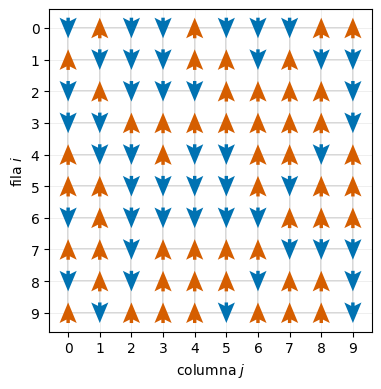

<Axes: xlabel='columna $j$', ylabel='fila $i$'>

In [14]:
# Configuración aleatoria de ejemplo para L = 10

red_visual = RedIsing2D(L=10, frontera="periodica")

espines_visual = asignar_espines_aleatorios(
    red_visual,
    p_arriba=0.5,
    semilla=42
)

graficar_configuracion(
    red_visual,
    espines_visual,
    tam_flecha=0.65,
    ancho_flecha=0.025,
    tam_cabeza=5
)

In [15]:
# Visualización en blanco y negro de la configuración L = 10
graficar_configuracion_bn(red_visual, espines_visual)

NameError: name 'graficar_configuracion_bn' is not defined

### Visualización para diferentes tamaños de red

La representación en blanco y negro se vuelve especialmente informativa a
medida que aumenta el tamaño $L$ de la red.

En este reto trabajaremos con

$$
L=10,\;15,\;20,\;25,\;30.
$$

Para una configuración aleatoria con

$$
P(s_i=+1)=P(s_i=-1)=\frac{1}{2},
$$

los espines se asignan independientemente y no presentan correlaciones
espaciales. Por esta razón, la configuración tiene una apariencia similar
a un ruido aleatorio.

A medida que aumenta $L$, esta representación permite observar con mayor
claridad la estructura espacial del sistema. Posteriormente, después de
aplicar la dinámica de Monte Carlo, podremos comparar estas configuraciones
aleatorias con las configuraciones térmicas: a temperaturas bajas aparecerán
dominios extensos de espines alineados, mientras que a temperaturas altas
predominará una estructura desordenada.

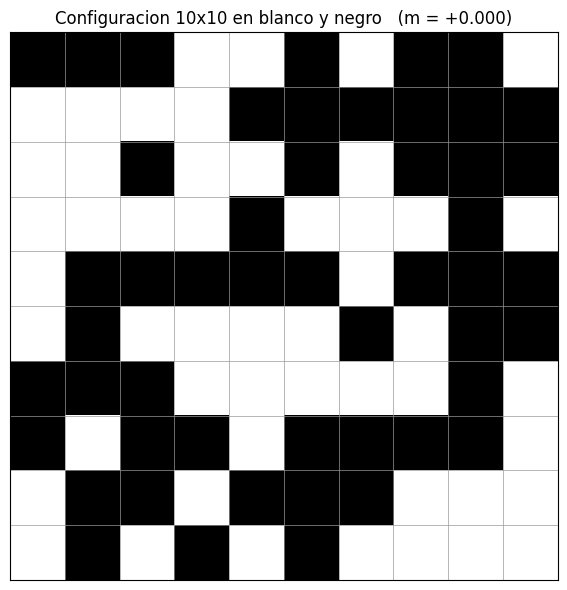

<Axes: title={'center': 'Configuracion 10x10 en blanco y negro   (m = +0.000)'}>

In [ ]:
# Configuración aleatoria de una red grande: L = 30

red_grande = RedIsing2D(
    L=30,
    frontera="periodica"
)

espines_grande = asignar_espines_aleatorios(
    red_grande,
    p_arriba=0.5,
    semilla=7
)

graficar_configuracion_bn(
    red_grande,
    espines_grande
)

## 3. Dinámica de Monte Carlo: algoritmo de Metropolis

Una vez definida una configuración de espines, queremos generar configuraciones
representativas del equilibrio térmico a una temperatura $T$.

En unidades normalizadas,

$$
J=1,
\qquad
k_B=1,
$$

el Hamiltoniano del modelo de Ising 2D es

$$
H(\{s\})=-J\sum_{\langle i,j\rangle}s_i s_j,
$$

donde la suma se realiza sobre pares de primeros vecinos y cada enlace se
cuenta una sola vez.

En equilibrio térmico, la probabilidad de una configuración está determinada
por la distribución de Boltzmann,

$$
P(\{s\})=
\frac{1}{Z}
\exp\left[-\frac{H(\{s\})}{T}\right],
$$

donde $Z$ es la función de partición.

### Paso de Metropolis

Para generar configuraciones térmicas se utiliza el algoritmo de Metropolis.
Para un espín $s_i$ se propone el cambio

$$
s_i\rightarrow -s_i.
$$

El cambio de energía asociado es

$$
\Delta E
=
2Js_i
\sum_{j\in\mathrm{vec}(i)}s_j.
$$

La propuesta se acepta con probabilidad

$$
p_{\mathrm{acc}}
=
\min\left(1,e^{-\Delta E/T}\right).
$$

Por tanto:

- si $\Delta E\leq0$, el cambio se acepta siempre;
- si $\Delta E>0$, se acepta con probabilidad

$$
e^{-\Delta E/T}.
$$

Un **barrido de Monte Carlo** (*sweep*) corresponde aproximadamente a

$$
N=L^2
$$

intentos de actualización y constituye una unidad natural de tiempo de
Monte Carlo.

### Actualización vectorizada y tamaños de red

Para redes cuadradas de tamaño par puede utilizarse una actualización
vectorizada tipo tablero de ajedrez: los sitios se dividen en dos subredes y
se actualiza primero una y después la otra.

Sin embargo, en este reto estudiaremos

$$
L=10,\;15,\;20,\;25,\;30,
$$

que incluye tamaños pares e impares.

Con condiciones de frontera periódicas, la descomposición bipartita tipo
tablero de ajedrez requiere especial cuidado cuando $L$ es impar. Por esta
razón, la implementación de Monte Carlo deberá garantizar que el algoritmo
utilizado sea válido de manera consistente para todos los tamaños considerados.

### Recorrido de temperaturas

Para calcular observables puede recorrerse la temperatura desde valores altos
hacia valores bajos. Se comienza con una configuración aleatoria a temperatura
alta y, después de alcanzar el equilibrio, la configuración final puede
utilizarse como condición inicial de la siguiente temperatura.

Este procedimiento reduce el tiempo necesario para alcanzar el equilibrio en
cada punto. No obstante, se mantendrá una etapa de termalización suficiente
para cada temperatura antes de guardar configuraciones o calcular observables.

El objetivo final será generar datos comparables para

$$
L=10,\;15,\;20,\;25,\;30
$$

y estudiar posteriormente la dependencia de la temperatura crítica estimada

$$
T_c(L)
$$

con el tamaño del sistema.

In [16]:
C_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))
# ~2.269185, temperatura crítica exacta de Onsager (J/k_B)


class IsingMetropolis:
    """
    Dinámica de Metropolis para el modelo de Ising 2D.

    Esta implementación utiliza actualizaciones secuenciales aleatorias,
    por lo que funciona de forma consistente tanto para tamaños pares
    como impares con frontera periódica.

    Unidades normalizadas:
        J = 1
        k_B = 1

    Hamiltoniano:
        H = -J * sum_<ij> s_i s_j

    Parámetros
    ----------
    L : int
        Tamaño lineal de la red.
    T : float
        Temperatura en unidades de J/k_B.
    frontera : str
        'periodica' o 'libre'.
    espines : np.ndarray, opcional
        Configuración inicial de forma (L,L) o (L*L,).
        Si es None se genera una configuración aleatoria.
    J : float
        Constante de acoplamiento.
    semilla : int o None
        Semilla del generador aleatorio.
    """

    def __init__(
        self,
        L,
        T,
        frontera="periodica",
        espines=None,
        J=1.0,
        semilla=None
    ):

        if frontera not in ("periodica", "libre"):
            raise ValueError(
                "frontera debe ser 'periodica' o 'libre'"
            )

        self.L = int(L)
        self.N = self.L * self.L
        self.frontera = frontera
        self.J = float(J)

        self.rng = np.random.default_rng(semilla)

        # Activa el setter y calcula beta = 1/T
        self.T = T

        # Configuración inicial
        if espines is None:

            self.s = self.rng.choice(
                np.array([-1, 1], dtype=np.int8),
                size=(self.L, self.L)
            )

        else:

            self.s = (
                np.asarray(espines, dtype=np.int8)
                .reshape(self.L, self.L)
                .copy()
            )

    @property
    def T(self):
        return self._T

    @T.setter
    def T(self, valor):

        valor = float(valor)

        if valor <= 0:
            raise ValueError("La temperatura debe ser mayor que cero.")

        self._T = valor
        self.beta = 1.0 / valor

    def _suma_vecinos_sitio(self, i, j):
        """
        Suma los primeros vecinos del sitio (i,j).
        """

        L = self.L

        if self.frontera == "periodica":

            return (
                self.s[(i - 1) % L, j]
                + self.s[(i + 1) % L, j]
                + self.s[i, (j - 1) % L]
                + self.s[i, (j + 1) % L]
            )

        # Frontera libre
        suma = 0

        if i > 0:
            suma += self.s[i - 1, j]

        if i < L - 1:
            suma += self.s[i + 1, j]

        if j > 0:
            suma += self.s[i, j - 1]

        if j < L - 1:
            suma += self.s[i, j + 1]

        return suma

    def barrido(self):
        """
        Un barrido de Monte Carlo.

        Se realizan N = L^2 intentos de actualización.
        En cada intento se selecciona aleatoriamente un sitio.
        """

        L = self.L

        for _ in range(self.N):

            # Elegir un sitio aleatoriamente
            i = self.rng.integers(0, L)
            j = self.rng.integers(0, L)

            si = self.s[i, j]

            # Suma de primeros vecinos
            vecinos = self._suma_vecinos_sitio(i, j)

            # Cambio de energía al voltear el espín
            dE = 2.0 * self.J * si * vecinos

            # Criterio de Metropolis
            if dE <= 0.0:

                self.s[i, j] = -si

            elif self.rng.random() < np.exp(-self.beta * dE):

                self.s[i, j] = -si

    def termalizar(self, n_barridos):
        """
        Ejecuta n_barridos sin realizar mediciones.
        """

        for _ in range(int(n_barridos)):
            self.barrido()

    def energia(self):
        """
        Energía total:

        E = -J sum_<ij> s_i s_j

        Cada enlace se cuenta una sola vez.
        """

        s = self.s.astype(np.int64)

        if self.frontera == "periodica":

            pares = s * (
                np.roll(s, -1, axis=0)
                + np.roll(s, -1, axis=1)
            )

            return -self.J * float(pares.sum())

        # Frontera libre
        pares = (
            (s[:-1, :] * s[1:, :]).sum()
            + (s[:, :-1] * s[:, 1:]).sum()
        )

        return -self.J * float(pares)

    def magnetizacion(self):
        """
        Magnetización total M = sum_i s_i.
        """

        return int(
            self.s.sum(dtype=np.int64)
        )

    def configuracion(self):
        """
        Devuelve una copia de la configuración actual
        como matriz L x L de valores ±1.
        """

        return self.s.copy()

## 4. Observables: energía, magnetización, calor específico y susceptibilidad

Una vez implementada la dinámica de Monte Carlo, podemos calcular diferentes
observables físicos en equilibrio térmico.

Como en este reto compararemos sistemas de diferentes tamaños,

$$
L=10,\;15,\;20,\;25,\;30,
$$

todas las cantidades extensivas se normalizan por el número total de sitios,

$$
N=L^2,
$$

de manera que los resultados puedan compararse entre redes de distinto tamaño.

Los promedios $\langle\cdot\rangle$ corresponden a configuraciones obtenidas
en equilibrio térmico a una misma temperatura $T$.

| Observable | Definición | Comportamiento esperado |
|---|---|---|
| Energía por sitio | $u=\frac{\langle H\rangle}{N}$ | Para frontera periódica, $u\rightarrow -2J$ cuando $T\rightarrow0$, mientras que $u\rightarrow0$ a temperaturas altas. |
| Magnetización por sitio | $m=\frac{\langle |M|\rangle}{N}$, con $M=\sum_i s_i$ | Se utiliza $|M|$ para evitar la cancelación entre los estados magnetizados positivo y negativo en un sistema finito. A baja temperatura $m\rightarrow1$ y a alta temperatura $m\rightarrow0$. |
| Calor específico por sitio | $c_V=\frac{\langle H^2\rangle-\langle H\rangle^2}{NT^2}$ | Presenta un máximo en la región de transición. En el límite termodinámico del modelo de Ising 2D, el calor específico presenta una divergencia logarítmica en $T_c$. |
| Susceptibilidad magnética por sitio | $\chi=\frac{\langle M^2\rangle-\langle |M|\rangle^2}{NT}$ | Presenta un máximo pronunciado cerca de la región crítica y permite estudiar el desplazamiento de la transición debido al tamaño finito. |

En unidades normalizadas,

$$
J=k_B=1,
$$

la temperatura crítica exacta del modelo de Ising bidimensional con red
cuadrada en el límite termodinámico es

$$
T_c^{(\infty)}
=
\frac{2}{\ln(1+\sqrt{2})}
\approx 2.269185.
$$

Para una red finita no esperamos observar una transición perfectamente
singular. En su lugar, los máximos del calor específico y de la
susceptibilidad se redondean y pueden desplazarse con respecto al valor
del sistema infinito. Este comportamiento constituye una manifestación de
los efectos de tamaño finito.

La función `medir_observables` realizará una etapa de termalización y,
posteriormente, calculará promedios sobre configuraciones de equilibrio,
separando las mediciones mediante varios barridos para reducir la
autocorrelación.

La función `barrido_annealing` aplicará este procedimiento a una secuencia
de temperaturas recorrida desde temperaturas altas hacia temperaturas bajas.

Posteriormente podremos comparar los resultados obtenidos para

$$
L=10,\;15,\;20,\;25,\;30
$$

y estudiar cómo las características de la región crítica evolucionan al
aumentar el tamaño del sistema.

In [17]:
import pandas as pd


def medir_observables(
    mc,
    n_termalizacion=2000,
    n_medidas=3000,
    submuestreo=5,
    guardar_configs=False
):
    """
    Termaliza el simulador `mc` a su temperatura actual y estima
    observables físicos por sitio.

    Parámetros
    ----------
    mc : IsingMetropolis
        Simulador ya construido.
    n_termalizacion : int
        Número de barridos descartados antes de medir.
    n_medidas : int
        Número total de barridos durante la etapa de medición.
    submuestreo : int
        Se registra una medida cada `submuestreo` barridos.
    guardar_configs : bool
        Si True, guarda también las configuraciones muestreadas.

    Devuelve
    --------
    obs : dict
        T, u, m, cv, chi, errores simples y número de muestras.

    configs : list[np.ndarray]
        Solo se devuelve si guardar_configs=True.
    """

    N = mc.N
    T = mc.T

    # -----------------------------
    # Termalización
    # -----------------------------
    mc.termalizar(n_termalizacion)

    E = []
    M_abs = []
    M2 = []
    configs = []

    # -----------------------------
    # Mediciones
    # -----------------------------
    for t in range(int(n_medidas)):

        mc.barrido()

        if t % submuestreo == 0:

            e_tot = mc.energia()
            m_tot = mc.magnetizacion()

            E.append(e_tot)
            M_abs.append(abs(m_tot))
            M2.append(m_tot * m_tot)

            if guardar_configs:
                configs.append(mc.configuracion())

    E = np.asarray(E, dtype=float)
    M_abs = np.asarray(M_abs, dtype=float)
    M2 = np.asarray(M2, dtype=float)

    # -----------------------------
    # Observables
    # -----------------------------
    u = E.mean() / N

    m = M_abs.mean() / N

    cv = E.var(ddof=1) / (N * T**2)

    chi = (
        M2.mean() - M_abs.mean()**2
    ) / (N * T)

    # Errores estadísticos simples
    u_err = E.std(ddof=1) / np.sqrt(len(E)) / N

    m_err = (
        M_abs.std(ddof=1)
        / np.sqrt(len(M_abs))
        / N
    )

    obs = {
        "T": T,
        "u": u,
        "m": m,
        "cv": cv,
        "chi": chi,
        "u_err": u_err,
        "m_err": m_err,
        "n_muestras": len(E),
    }

    if guardar_configs:
        return obs, configs

    return obs


def barrido_annealing(
    L,
    temperaturas,
    frontera="periodica",
    J=1.0,
    n_termalizacion=1500,
    n_medidas=3000,
    submuestreo=5,
    semilla=0,
    verbose=True
):
    """
    Recorre las temperaturas de mayor a menor y calcula
    los observables físicos por sitio.

    La configuración final obtenida a una temperatura se utiliza
    como configuración inicial de la temperatura inmediatamente
    inferior.

    Devuelve
    --------
    df : pandas.DataFrame
        Columnas T, u, m, cv, chi, errores y número de muestras.
    """

    temperaturas = np.sort(
        np.asarray(temperaturas, dtype=float)
    )[::-1]

    mc = IsingMetropolis(
        L=L,
        T=temperaturas[0],
        frontera=frontera,
        J=J,
        semilla=semilla
    )

    filas = []

    for k, T in enumerate(temperaturas):

        # Cambiar temperatura conservando
        # la configuración actual
        mc.T = T

        obs = medir_observables(
            mc,
            n_termalizacion=n_termalizacion,
            n_medidas=n_medidas,
            submuestreo=submuestreo
        )

        filas.append(obs)

        if verbose:

            print(
                f"L={L:2d}   "
                f"[{k + 1:2d}/{len(temperaturas)}]   "
                f"T={T:5.3f}   "
                f"u={obs['u']:+.3f}   "
                f"m={obs['m']:.3f}   "
                f"cv={obs['cv']:.3f}   "
                f"chi={obs['chi']:8.3f}"
            )

    return pd.DataFrame(filas)

### Promedio configuracional: varias realizaciones

Un solo recorrido de recocido corresponde a **una realización**: una trayectoria
particular de la cadena de Markov, determinada por su configuración inicial y
por la secuencia de números aleatorios utilizada durante la simulación.

Los observables obtenidos en una única realización presentan fluctuaciones
estadísticas, especialmente cerca de la temperatura crítica, donde aumentan
las fluctuaciones y la autocorrelación debido al *critical slowing down*.

Por esta razón, una sola realización no representa por sí sola el comportamiento
promedio del sistema. Para obtener estimaciones más robustas se realizan
$R$ cadenas de Monte Carlo independientes.

Si $A^{(r)}(T)$ representa el valor de un observable obtenido en la realización
$r$, el promedio entre realizaciones se calcula como

$$
\overline{A}(T)
=
\frac{1}{R}
\sum_{r=1}^{R}
A^{(r)}(T).
$$

La dispersión entre realizaciones puede caracterizarse mediante la desviación
estándar

$$
\sigma_R(A)
=
\sqrt{
\frac{1}{R-1}
\sum_{r=1}^{R}
\left[
A^{(r)}(T)-\overline{A}(T)
\right]^2
},
$$

mientras que el error estándar de la media se estima como

$$
\mathrm{SEM}(T)
=
\frac{\sigma_R(A)}{\sqrt{R}}.
$$

En el reto de escalamiento este procedimiento se realizará para cada uno de
los tamaños

$$
L=10,\;15,\;20,\;25,\;30.
$$

De esta forma podremos distinguir, al menos parcialmente, las fluctuaciones
debidas a las diferentes realizaciones Monte Carlo de la dependencia
sistemática con el tamaño del sistema.

La función `curvas_promedio` realizará $R$ simulaciones independientes para
un mismo valor de $L$. Las semillas de las diferentes realizaciones se
generarán a partir de una `SeedSequence`, garantizando secuencias
reproducibles pero independientes.

La función devolverá:

- `resumen`: media, desviación estándar y error estándar de los observables
  para cada temperatura.
- `crudo`: resultados individuales de todas las realizaciones.

Una única realización seguirá pudiendo obtenerse mediante

`barrido_annealing(L, temperaturas, semilla=0)`.

In [18]:
def curvas_promedio(L, temperaturas, n_realizaciones=6, frontera='periodica', J=1.0,
                    n_termalizacion=1200, n_medidas=2500, submuestreo=5, semilla=0,
                    verbose=True):
    """Promedio configuracional: repite el recocido `n_realizaciones` veces (cadenas
    de Monte Carlo independientes) y promedia los observables por temperatura.

    Cada realizacion recorre `temperaturas` de alta a baja (ver `barrido_annealing`).
    Las semillas de las realizaciones son hijas de una misma SeedSequence: son
    independientes y el resultado es reproducible a partir de `semilla`.

    Devuelve
    --------
    resumen : DataFrame  (una fila por temperatura, de T alta a baja)
        Columnas: T, u, u_err, m, m_err, cv, cv_err, chi, chi_err, n_realizaciones.
        *_err es el error estandar de la media entre realizaciones (sigma/sqrt(R)).
    crudo : DataFrame
        Todas las realizaciones apiladas, con la columna 'realizacion' (0..R-1).
    """
    semillas_hijas = np.random.SeedSequence(semilla).spawn(n_realizaciones)

    dfs = []
    for r, sem in enumerate(semillas_hijas):
        df_r = barrido_annealing(L, temperaturas, frontera=frontera, J=J,
                                 n_termalizacion=n_termalizacion, n_medidas=n_medidas,
                                 submuestreo=submuestreo, semilla=sem, verbose=False)
        df_r['realizacion'] = r
        dfs.append(df_r)
        if verbose:
            print(f"realizacion {r + 1}/{n_realizaciones} lista")

    crudo = pd.concat(dfs, ignore_index=True)

    g = crudo.groupby('T', sort=False)
    resumen = pd.DataFrame({
        'T':   list(g.groups.keys()),
        'u':   g['u'].mean().values,     'u_err':   g['u'].sem().values,
        'm':   g['m'].mean().values,     'm_err':   g['m'].sem().values,
        'cv':  g['cv'].mean().values,    'cv_err':  g['cv'].sem().values,
        'chi': g['chi'].mean().values,   'chi_err': g['chi'].sem().values,
        'n_realizaciones': g.size().values,
    }).sort_values('T', ascending=False).reset_index(drop=True)

    return resumen, crudo


In [19]:
# Prueba del promedio configuracional para L = 10
# R cadenas de Monte Carlo independientes.
# Cada realización recorre las temperaturas de ALTA a BAJA.

L = 10

temperaturas = np.concatenate([
    np.linspace(3.60, 2.60, 6),     # T > Tc: fase desordenada
    np.linspace(2.50, 2.05, 12),    # entorno de Tc: rejilla más fina
    np.linspace(1.95, 1.00, 10),    # T < Tc: fase ordenada
])

resumen, crudo = curvas_promedio(
    L=L,
    temperaturas=temperaturas,
    n_realizaciones=6,
    frontera="periodica",
    n_termalizacion=1200,
    n_medidas=2500,
    submuestreo=5,
    semilla=0,
)

resumen.round(4)

realizacion 1/6 lista
realizacion 2/6 lista
realizacion 3/6 lista
realizacion 4/6 lista
realizacion 5/6 lista
realizacion 6/6 lista


,T,u,u_err,m,m_err,cv,cv_err,chi,chi_err,n_realizaciones
0,3.6000,-0.6372,0.0022,0.1965,0.0027,0.2233,0.0055,0.5567,0.0109,6
1,3.4000,-0.6861,0.0021,0.2057,0.0038,0.2689,0.0081,0.6676,0.0204,6
2,3.2000,-0.7492,0.0039,0.2396,0.0048,0.3333,0.0106,0.8923,0.0151,6
3,3.0000,-0.8178,0.0041,0.2720,0.0042,0.4161,0.0110,1.1749,0.0410,6
4,2.8000,-0.9290,0.0092,0.3451,0.0099,0.6031,0.0243,1.7278,0.0381,6
5,2.6000,-1.0840,0.0066,0.4568,0.0087,0.8801,0.0281,2.3248,0.0719,6
6,2.5000,-1.1805,0.0024,0.5326,0.0062,1.1346,0.0233,2.6783,0.0689,6
7,2.4591,-1.2406,0.0071,0.5831,0.0057,1.1879,0.0154,2.5336,0.0636,6
8,2.4182,-1.2857,0.0103,0.6192,0.0140,1.2144,0.0298,2.4168,0.1553,6
9,2.3773,-1.3283,0.0069,0.6451,0.0086,1.2961,0.0362,2.5021,0.1529,6


### Curvas promedio y $c_V$ frente a la magnetización

Las siguientes gráficas muestran el comportamiento de los observables
termodinámicos obtenidos mediante Monte Carlo.

Para cada observable se representan:

- las **realizaciones individuales**, mediante líneas tenues, correspondientes
  a cadenas de Monte Carlo independientes;
- el **promedio configuracional**, acompañado por barras de error que
  representan la media $\pm$ el error estándar entre realizaciones.

Para la red $L=10$ esperamos observar que, lejos de la región crítica, las
diferentes realizaciones presentan poca dispersión. Cerca de la transición,
en cambio, las fluctuaciones aumentan y las diferencias entre realizaciones
se hacen más visibles.

Al disminuir la temperatura se espera el siguiente comportamiento:

- la energía por sitio $u$ evoluciona hacia $-2J$;
- la magnetización absoluta por sitio $|m|$ aumenta desde valores pequeños
  hacia $1$;
- el calor específico $c_V$ presenta un máximo en la región crítica;
- la susceptibilidad $\chi$ también presenta un máximo pronunciado cerca de
  la transición.

Para una red finita estos máximos son redondeados y su posición puede estar
desplazada respecto a la temperatura crítica de Onsager,

$$
T_c^{(\infty)} \approx 2.269185.
$$

Este desplazamiento es relevante para el reto de escalamiento, ya que
posteriormente compararemos sistemas con

$$
L=10,\;15,\;20,\;25,\;30
$$

para estudiar cómo cambia la región crítica al aumentar el tamaño de la red.

En la representación $c_V$ frente a $|m|$, cada punto corresponde a una
temperatura del promedio configuracional. A temperaturas altas el sistema
presenta magnetización pequeña; al aproximarse a la región crítica aumenta
$c_V$ y, al continuar enfriando, la magnetización se aproxima a $1$ mientras
$c_V$ vuelve a disminuir.

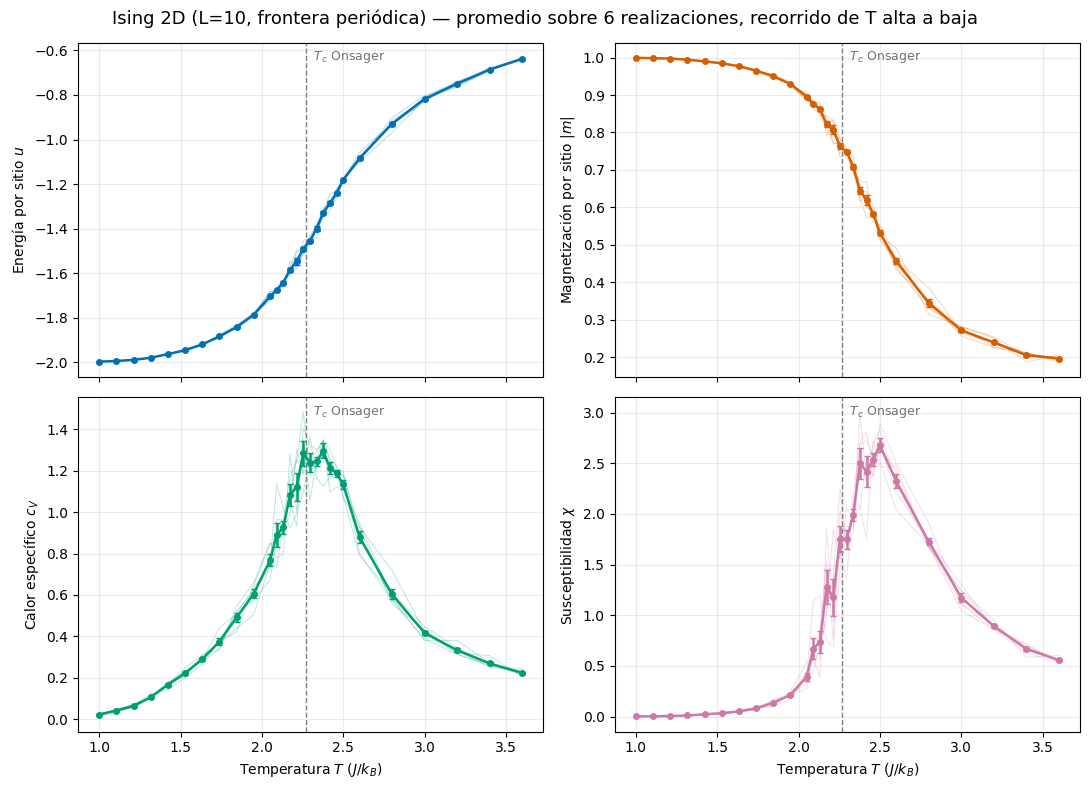

In [21]:
# Observables por sitio frente a T:
# realizaciones individuales (tenues) + promedio configuracional (con error)

# Temperatura crítica exacta de Onsager
Tc = C_ONSAGER

fig, axes = plt.subplots(
    2, 2,
    figsize=(11, 8),
    sharex=True
)

# Observable y etiqueta de cada panel
paneles = [
    ('u',   r'Energía por sitio $u$'),
    ('m',   r'Magnetización por sitio $|m|$'),
    ('cv',  r'Calor específico $c_V$'),
    ('chi', r'Susceptibilidad $\chi$'),
]

# Colores para cada observable
colores = [
    '#0072B2',
    '#D55E00',
    '#009E73',
    '#CC79A7'
]

# ---------------------------------------------------------
# Construcción de los cuatro paneles
# ---------------------------------------------------------
for ax, (col, etiqueta), color in zip(
    axes.flat,
    paneles,
    colores
):

    # Realizaciones individuales
    for _, sub in crudo.groupby('realizacion'):

        sub = sub.sort_values(
            'T',
            ascending=False
        )

        ax.plot(
            sub['T'],
            sub[col],
            '-',
            color=color,
            lw=0.7,
            alpha=0.25,
            zorder=1
        )

    # Promedio configuracional con error estándar
    ax.errorbar(
        resumen['T'],
        resumen[col],
        yerr=resumen[col + '_err'],
        fmt='o-',
        color=color,
        lw=1.8,
        ms=4,
        capsize=2,
        zorder=3
    )

    # Temperatura crítica exacta de Onsager
    ax.axvline(
        Tc,
        color='0.5',
        ls='--',
        lw=1
    )

    ax.text(
        Tc,
        0.98,
        r'  $T_c$ Onsager',
        transform=ax.get_xaxis_transform(),
        va='top',
        ha='left',
        color='0.45',
        fontsize=9
    )

    ax.set_ylabel(etiqueta)
    ax.grid(alpha=0.25)


# Etiqueta del eje X en los paneles inferiores
for ax in axes[1, :]:

    ax.set_xlabel(
        r'Temperatura $T$ ($J/k_B$)'
    )


# Número de realizaciones
R = int(
    resumen['n_realizaciones'].iloc[0]
)


# Título general
fig.suptitle(
    f'Ising 2D (L={L}, frontera periódica) — '
    f'promedio sobre {R} realizaciones, '
    f'recorrido de T alta a baja',
    fontsize=13
)


fig.tight_layout()

plt.show()

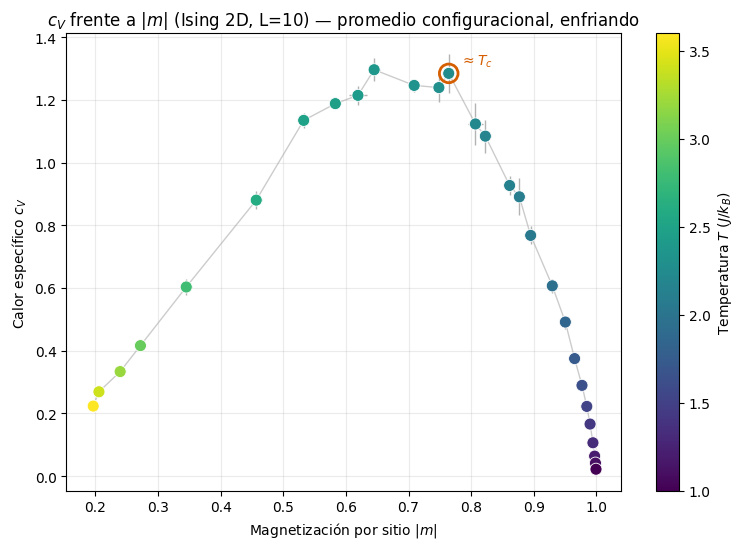

In [22]:
# c_V frente a |m| (promedio configuracional),
# con la temperatura codificada en color.

mvals = resumen['m'].to_numpy()
cvvals = resumen['cv'].to_numpy()
m_err = resumen['m_err'].to_numpy()
cv_err = resumen['cv_err'].to_numpy()
Tvals = resumen['T'].to_numpy()

fig, ax = plt.subplots(figsize=(7.8, 5.6))

# Barras de error
ax.errorbar(
    mvals,
    cvvals,
    xerr=m_err,
    yerr=cv_err,
    fmt='none',
    ecolor='0.7',
    elinewidth=1,
    zorder=1
)

# Línea que conecta los puntos
ax.plot(
    mvals,
    cvvals,
    '-',
    color='0.8',
    lw=1,
    zorder=1
)

# Puntos coloreados según la temperatura
sc = ax.scatter(
    mvals,
    cvvals,
    c=Tvals,
    cmap='viridis',
    s=75,
    zorder=2,
    edgecolors='white',
    linewidths=0.6
)

# Barra de temperatura
cb = fig.colorbar(sc, ax=ax)
cb.set_label(r'Temperatura $T$ ($J/k_B$)')

# -------------------------------------------------------
# Punto de la malla más cercano a Tc de Onsager
# -------------------------------------------------------
k_c = int(
    np.argmin(
        np.abs(Tvals - C_ONSAGER)
    )
)

ax.scatter(
    [mvals[k_c]],
    [cvvals[k_c]],
    s=180,
    facecolors='none',
    edgecolors='#D55E00',
    linewidths=2,
    zorder=3
)

ax.annotate(
    r'$\approx T_c$',
    (mvals[k_c], cvvals[k_c]),
    textcoords='offset points',
    xytext=(8, 6),
    color='#D55E00'
)

# -------------------------------------------------------
# Formato
# -------------------------------------------------------
ax.set_xlabel(
    r'Magnetización por sitio $|m|$'
)

ax.set_ylabel(
    r'Calor específico $c_V$'
)

ax.set_title(
    f'$c_V$ frente a $|m|$ '
    f'(Ising 2D, L={L}) — '
    f'promedio configuracional, enfriando'
)

ax.grid(alpha=0.25)

fig.tight_layout()

plt.show()


## 5. Construcción de los datasets: configuraciones etiquetadas por fase

### 5.1 Objetivo

En la sección anterior estudiamos observables termodinámicos obtenidos mediante
promedios sobre muchas configuraciones. Para entrenar una red neuronal necesitamos
conservar, en cambio, las **configuraciones completas de espines**.

Cada ejemplo de entrada será una matriz

$$
X\in\{-1,+1\}^{L\times L},
$$

que representa una configuración microscópica del modelo de Ising.

En este reto generaremos datasets independientes para

$$
L=10,\;15,\;20,\;25,\;30.
$$

Esto permitirá entrenar posteriormente un clasificador para cada tamaño del
sistema y obtener una estimación

$$
T_c(L)
$$

que pueda compararse con la temperatura crítica exacta de Onsager en el
límite termodinámico,

$$
T_c^{(\infty)}
=
\frac{2}{\ln(1+\sqrt{2})}
\approx 2.269185.
$$


### 5.2 Etiquetas de las fases

Utilizaremos la convención

| Fase | Etiqueta | Región |
|---|---:|---|
| Ordenada | `y = 0` | $T<T_c$ |
| Desordenada | `y = 1` | $T>T_c$ |

En la fase ordenada aparecen grandes dominios de espines alineados y
$|m|$ toma valores elevados.

En la fase desordenada las configuraciones presentan una estructura mucho
más irregular y la magnetización absoluta disminuye.

Sin embargo, no utilizaremos temperaturas demasiado próximas a $T_c$ para
construir el conjunto de entrenamiento. Dejaremos una banda alrededor de la
transición sin etiquetas de entrenamiento.

Esto obliga al clasificador a aprender las características de las dos fases
a partir de ejemplos claramente ordenados y claramente desordenados.

Posteriormente evaluaremos el modelo precisamente dentro de la región crítica.


### 5.3 Configuraciones almacenadas por temperatura

Para cada tamaño $L$, temperatura $T$ y realización independiente:

1. se termaliza el sistema durante `n_termalizacion` barridos;
2. se generan `n_config_por_T` configuraciones;
3. las configuraciones consecutivas se separan mediante
   `barridos_entre_config` barridos de Monte Carlo;
4. las temperaturas que satisfacen

$$
|T-T_c|<\mathrm{margen}
$$

se excluyen del conjunto de entrenamiento.

El número total de configuraciones para cada tamaño será

$$
N_{\mathrm{datos}}
=
n_{\mathrm{realizaciones}}\,
n_T^{(\mathrm{válidas})}\,
n_{\mathrm{config\ por\ }T}.
$$

Cada configuración constituye un ejemplo independiente para el clasificador.


### 5.4 Simetría global $s_i\rightarrow -s_i$

El Hamiltoniano de Ising sin campo externo es invariante bajo la transformación

$$
s_i\rightarrow -s_i
$$

aplicada simultáneamente a todos los espines.

Por esta razón existen dos estados ordenados equivalentes, uno con
magnetización positiva y otro con magnetización negativa.

Para evitar que la red neuronal aprenda artificialmente que el signo de la
magnetización determina la fase, utilizaremos `simetrizar=True`.

Al almacenar cada configuración se realizará, con probabilidad $1/2$,

$$
X\rightarrow-X.
$$

Esta transformación conserva la energía, la fase y $|m|$, pero equilibra las
dos orientaciones posibles de la fase ferromagnética.


### 5.5 Estructura de los datasets

Para cada tamaño del sistema almacenaremos un archivo independiente:

- `ising_dataset_L10.npz`
- `ising_dataset_L15.npz`
- `ising_dataset_L20.npz`
- `ising_dataset_L25.npz`
- `ising_dataset_L30.npz`

Cada archivo contendrá:

| Clave | Forma | Significado |
|---|---|---|
| `X` | `(N,L,L)` | configuraciones completas de espines |
| `y` | `(N,)` | etiqueta de fase: 0 ordenada, 1 desordenada |
| `T` | `(N,)` | temperatura de generación |
| `m` | `(N,)` | magnetización absoluta por sitio |
| `realizacion` | `(N,)` | cadena Monte Carlo de origen |
| `Tc` | escalar | temperatura crítica de Onsager usada como referencia |
| `L` | escalar | tamaño lineal |
| `frontera` | escalar | condición de frontera |

Las variables `T`, `m` y `realizacion` se conservarán como metadatos para
el análisis posterior.


### 5.6 Entrada al MLP

Para cada tamaño $L$, las configuraciones

$$
(L,L)
$$

se aplanarán como vectores de longitud

$$
L^2.
$$

Por tanto, la dimensión de entrada del `MLPClassifier` será diferente para
cada sistema:

$$
L=10 \Rightarrow 100,
$$

$$
L=15 \Rightarrow 225,
$$

$$
L=20 \Rightarrow 400,
$$

$$
L=25 \Rightarrow 625,
$$

$$
L=30 \Rightarrow 900.
$$

Se entrenará un nuevo `MLPClassifier` para cada tamaño.

Posteriormente generaremos configuraciones en una malla fina de temperaturas
alrededor de la transición y calcularemos

$$
\left\langle P(y=1\mid X)\right\rangle(T).
$$

Para cada $L$ definiremos la temperatura crítica estimada mediante el cruce

$$
\left\langle P(y=1\mid X)\right\rangle=0.5.
$$

Finalmente compararemos

$$
T_c(10),\;
T_c(15),\;
T_c(20),\;
T_c(25),\;
T_c(30)
$$

con $T_c^{(\infty)}$ de Onsager para estudiar los efectos de tamaño finito.

In [23]:
def generar_dataset_ising(
    L,
    temperaturas,
    n_config_por_T,
    n_realizaciones=1,
    frontera='periodica',
    J=1.0,
    n_termalizacion=2000,
    barridos_entre_config=25,
    margen=0.15,
    simetrizar=True,
    semilla=0,
    verbose=True
):
    """
    Genera configuraciones del modelo de Ising etiquetadas por fase.

    Para cada realización independiente se recorren las temperaturas
    de mayor a menor. En cada temperatura se termaliza el sistema y
    posteriormente se almacenan configuraciones separadas mediante
    varios barridos de Monte Carlo.

    Las temperaturas dentro de la banda

        |T - Tc| < margen

    no se utilizan para entrenamiento.

    Etiquetas
    ---------
    y = 0 : fase ordenada     (T < Tc)
    y = 1 : fase desordenada  (T > Tc)

    Devuelve
    --------
    X : ndarray, shape (N, L, L)
        Configuraciones de espines ±1.

    T : ndarray, shape (N,)
        Temperatura de cada configuración.

    y : ndarray, shape (N,)
        Etiqueta de fase.

    m : ndarray, shape (N,)
        Magnetización absoluta por sitio.

    realizacion : ndarray, shape (N,)
        Realización Monte Carlo de origen.
    """

    # --------------------------------------------------
    # Temperaturas de alta a baja
    # --------------------------------------------------
    temperaturas = np.sort(
        np.asarray(temperaturas, dtype=float)
    )[::-1]

    # Temperatura crítica exacta de Onsager
    Tc = C_ONSAGER

    # --------------------------------------------------
    # Generadores aleatorios independientes
    # --------------------------------------------------
    ss = np.random.SeedSequence(semilla)

    # RNG usado exclusivamente para la simetrización
    sim_rng = np.random.default_rng(
        ss.spawn(1)[0]
    )

    # Semillas independientes para las cadenas Monte Carlo
    semillas_cadenas = ss.spawn(n_realizaciones)

    # --------------------------------------------------
    # Contenedores
    # --------------------------------------------------
    X = []
    T_lista = []
    y_lista = []
    m_lista = []
    r_lista = []

    # Número de temperaturas utilizadas
    n_T_validas = int(
        (np.abs(temperaturas - Tc) >= margen).sum()
    )

    if verbose:
        print("=" * 55)
        print(f"Generando dataset para L = {L}")
        print(f"Sitios por configuración = {L * L}")
        print(f"Temperaturas totales      = {len(temperaturas)}")
        print(f"Temperaturas utilizadas   = {n_T_validas}")
        print(f"Realizaciones             = {n_realizaciones}")
        print(f"Configs por T             = {n_config_por_T}")
        print(
            "Total esperado           = "
            f"{n_realizaciones * n_T_validas * n_config_por_T}"
        )
        print("=" * 55)

    # --------------------------------------------------
    # Realizaciones independientes
    # --------------------------------------------------
    for r, sem in enumerate(semillas_cadenas):

        mc = IsingMetropolis(
            L=L,
            T=temperaturas[0],
            frontera=frontera,
            J=J,
            semilla=sem
        )

        # ----------------------------------------------
        # Recorrido de temperaturas
        # ----------------------------------------------
        for Temp in temperaturas:

            mc.T = Temp

            # Termalización
            mc.termalizar(n_termalizacion)

            # Excluir banda crítica del entrenamiento
            if abs(Temp - Tc) < margen:
                continue

            # ------------------------------------------
            # Generación de configuraciones
            # ------------------------------------------
            for _ in range(int(n_config_por_T)):

                # Separación entre configuraciones
                mc.termalizar(barridos_entre_config)

                conf = mc.configuracion()

                # Simetría global s -> -s
                if simetrizar and sim_rng.random() < 0.5:
                    conf = (-conf).astype(np.int8)

                X.append(conf)

                T_lista.append(Temp)

                # Etiqueta
                y_lista.append(
                    0 if Temp < Tc else 1
                )

                # Magnetización absoluta por sitio
                m_lista.append(
                    abs(
                        int(
                            conf.sum(dtype=np.int64)
                        )
                    ) / mc.N
                )

                # Realización de origen
                r_lista.append(r)

        if verbose:
            print(
                f"L={L:2d} | "
                f"realización {r + 1}/{n_realizaciones} lista | "
                f"{n_T_validas} temperaturas × "
                f"{n_config_por_T} configuraciones"
            )

    # --------------------------------------------------
    # Conversión a arrays
    # --------------------------------------------------
    X = np.asarray(
        X,
        dtype=np.int8
    )

    T_lista = np.asarray(
        T_lista,
        dtype=float
    )

    y_lista = np.asarray(
        y_lista,
        dtype=np.int8
    )

    m_lista = np.asarray(
        m_lista,
        dtype=float
    )

    r_lista = np.asarray(
        r_lista,
        dtype=np.int16
    )

    if verbose:
        print("-" * 55)
        print(f"Dataset L={L} terminado")
        print(f"X.shape = {X.shape}")
        print(f"y.shape = {y_lista.shape}")
        print(
            "Clases  =",
            np.bincount(y_lista)
        )
        print("-" * 55)

    return (
        X,
        T_lista,
        y_lista,
        m_lista,
        r_lista
    )

In [24]:
# ============================================================
# Dataset de entrenamiento para L = 10
# ============================================================

L_dataset = 10

# Temperaturas alejadas de la región crítica:
# 5 temperaturas desordenadas y 5 ordenadas.
temps_dataset = np.concatenate([
    np.linspace(3.50, 2.60, 5),    # T > Tc -> desordenada (y = 1)
    np.linspace(1.90, 1.20, 5),    # T < Tc -> ordenada    (y = 0)
])

# ------------------------------------------------------------
# Generación del dataset
# ------------------------------------------------------------

X, T_muestra, y, m_muestra, realizacion = generar_dataset_ising(
    L=L_dataset,
    temperaturas=temps_dataset,
    n_config_por_T=40,
    n_realizaciones=4,
    frontera='periodica',
    n_termalizacion=1500,
    barridos_entre_config=20,
    margen=0.0,
    simetrizar=True,
    semilla=1,
)

# ------------------------------------------------------------
# Información del dataset generado
# ------------------------------------------------------------

R = len(np.unique(realizacion))
n_T = len(np.unique(T_muestra))

print()
print("=" * 60)
print(f"RESUMEN DEL DATASET L = {L_dataset}")
print("=" * 60)

print(
    f"{R} realizaciones x "
    f"{n_T} temperaturas x "
    f"40 configuraciones = "
    f"{len(y)} configuraciones"
)

print(
    f"X: {X.shape}   "
    f"dtype={X.dtype}   "
    f"({X.nbytes / 1024:.0f} KiB en memoria)"
)

print(
    f"y = 1 (desordenada, T > Tc): "
    f"{(y == 1).sum()}"
)

print(
    f"y = 0 (ordenada, T < Tc): "
    f"{(y == 0).sum()}"
)

print(
    f"|m| medio -> "
    f"desordenada: {m_muestra[y == 1].mean():.3f}   "
    f"ordenada: {m_muestra[y == 0].mean():.3f}"
)

# ------------------------------------------------------------
# Comprobación de la simetrización
# ------------------------------------------------------------

indices_ordenados = np.where(y == 0)[0]

signo_ord = np.array([
    np.sign(X[k].sum())
    for k in indices_ordenados
])

print(
    f"fase ordenada: "
    f"{(signo_ord > 0).sum()} con m > 0 / "
    f"{(signo_ord < 0).sum()} con m < 0"
)

# ------------------------------------------------------------
# Guardar dataset
# ------------------------------------------------------------

ruta = f'ising_dataset_L{L_dataset}.npz'

np.savez_compressed(
    ruta,
    X=X,
    y=y,
    T=T_muestra,
    m=m_muestra,
    realizacion=realizacion,
    Tc=C_ONSAGER,
    L=np.int64(L_dataset),
    frontera='periodica',
)

print()
print(f"Dataset guardado en: {ruta}")

Generando dataset para L = 10
Sitios por configuración = 100
Temperaturas totales      = 10
Temperaturas utilizadas   = 10
Realizaciones             = 4
Configs por T             = 40
Total esperado           = 1600
L=10 | realización 1/4 lista | 10 temperaturas × 40 configuraciones
L=10 | realización 2/4 lista | 10 temperaturas × 40 configuraciones
L=10 | realización 3/4 lista | 10 temperaturas × 40 configuraciones
L=10 | realización 4/4 lista | 10 temperaturas × 40 configuraciones
-------------------------------------------------------
Dataset L=10 terminado
X.shape = (1600, 10, 10)
y.shape = (1600,)
Clases  = [800 800]
-------------------------------------------------------

RESUMEN DEL DATASET L = 10
4 realizaciones x 10 temperaturas x 40 configuraciones = 1600 configuraciones
X: (1600, 10, 10)   dtype=int8   (156 KiB en memoria)
y = 1 (desordenada, T > Tc): 800
y = 0 (ordenada, T < Tc): 800
|m| medio -> desordenada: 0.282   ordenada: 0.975
fase ordenada: 392 con m > 0 / 408 con m 

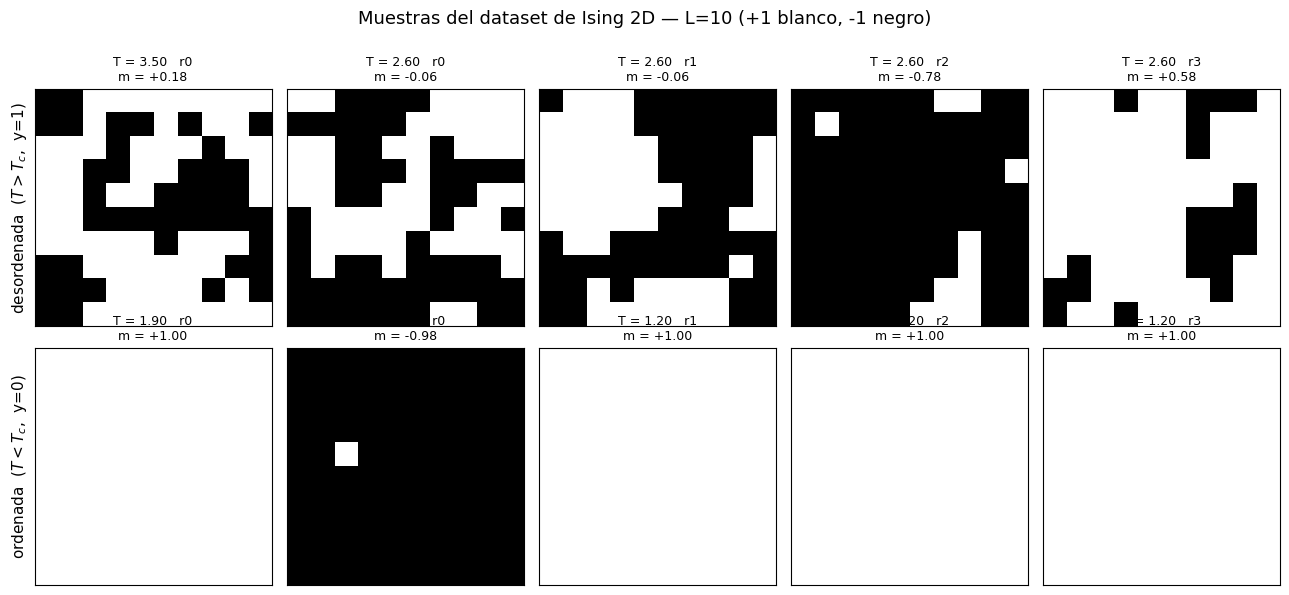

In [25]:
# ============================================================
# Muestras del dataset de entrenamiento para L = 10
# 5 configuraciones de cada fase
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(13, 5.8))

for fila, (fase, titulo) in enumerate([
    (1, 'desordenada  ($T > T_c$,  y=1)'),
    (0, 'ordenada  ($T < T_c$,  y=0)')
]):

    # Índices correspondientes a la fase
    idx = np.where(y == fase)[0]

    # Seleccionar 5 configuraciones distribuidas en el dataset
    sel = idx[
        np.linspace(
            0,
            len(idx) - 1,
            5
        ).astype(int)
    ]

    for ax, k in zip(axes[fila], sel):

        ax.imshow(
            X[k],
            cmap='gray',
            vmin=-1,
            vmax=1,
            interpolation='nearest'
        )

        ax.set_title(
            f'T = {T_muestra[k]:.2f}   '
            f'r{realizacion[k]}\n'
            f'm = {np.mean(X[k]):+.2f}',
            fontsize=9
        )

        ax.set_xticks([])
        ax.set_yticks([])

    axes[fila, 0].set_ylabel(
        titulo,
        fontsize=11
    )

fig.suptitle(
    f'Muestras del dataset de Ising 2D — '
    f'L={L_dataset} '
    f'(+1 blanco, -1 negro)',
    fontsize=13,
    y=1.02
)

fig.tight_layout()

plt.show()

In [26]:
# ============================================================
# Lectura del dataset de Ising para L = 10
# Preparación de los datos para el MLPClassifier
# ============================================================

L_dataset = 10

ruta_dataset = f'ising_dataset_L{L_dataset}.npz'

# ------------------------------------------------------------
# 1. Cargar dataset
# ------------------------------------------------------------

datos = np.load(
    ruta_dataset,
    allow_pickle=False
)

print("Archivo cargado:", ruta_dataset)
print("Claves:", list(datos.keys()))

# ------------------------------------------------------------
# 2. Extraer variables
# ------------------------------------------------------------

Xd = datos['X'].astype(np.float32)

yd = datos['y'].astype(np.int64)

Td = datos['T']

md = datos['m']

rd = datos['realizacion']

Ld = int(datos['L'])

Tcd = float(datos['Tc'])

N = len(yd)

print()
print("=" * 60)
print(f"DATASET L = {Ld}")
print("=" * 60)

print(
    f"N = {N} configuraciones de "
    f"{Ld} x {Ld}"
)

print(
    f"y = 0 (ordenada): "
    f"{(yd == 0).sum()}"
)

print(
    f"y = 1 (desordenada): "
    f"{(yd == 1).sum()}"
)

print(
    f"Tc de referencia = {Tcd:.6f}"
)

# ------------------------------------------------------------
# 3. Barajar las configuraciones
# ------------------------------------------------------------
# Las configuraciones originalmente están ordenadas por
# realización y temperatura.

rng = np.random.default_rng(0)

perm = rng.permutation(N)

Xd = Xd[perm]
yd = yd[perm]
Td = Td[perm]
md = md[perm]
rd = rd[perm]

# ------------------------------------------------------------
# 4. Preparar la entrada para las redes
# ------------------------------------------------------------

# MLP:
# cada configuración L x L se convierte en un vector L^2

X_mlp = Xd.reshape(
    N,
    Ld * Ld
)

# CNN:
# se conserva la estructura espacial L x L

X_cnn = Xd[:, :, :, None]

print()
print("Dimensiones de entrada:")
print(f"MLP : {X_mlp.shape}")
print(f"CNN : {X_cnn.shape}")

# ------------------------------------------------------------
# 5. División train / test
# ------------------------------------------------------------
# 80 % entrenamiento
# 20 % prueba
#
# Se mantiene el balance de las dos clases.

frac_test = 0.20

mask_test = np.zeros(
    N,
    dtype=bool
)

for c in (0, 1):

    idx_c = np.where(
        yd == c
    )[0]

    n_test_c = int(
        frac_test * len(idx_c)
    )

    mask_test[
        idx_c[:n_test_c]
    ] = True

# ------------------------------------------------------------
# 6. Conjuntos para el MLP
# ------------------------------------------------------------

X_train = X_mlp[~mask_test]
X_test  = X_mlp[mask_test]

y_train = yd[~mask_test]
y_test  = yd[mask_test]

# Metadatos del conjunto test
T_test = Td[mask_test]
m_test = md[mask_test]
r_test = rd[mask_test]

# ------------------------------------------------------------
# 7. Resumen
# ------------------------------------------------------------

print()
print("=" * 60)
print("PARTICIÓN TRAIN / TEST")
print("=" * 60)

print(
    f"train: {len(y_train)} "
    f"(y0={np.sum(y_train == 0)}, "
    f"y1={np.sum(y_train == 1)})"
)

print(
    f"test : {len(y_test)} "
    f"(y0={np.sum(y_test == 0)}, "
    f"y1={np.sum(y_test == 1)})"
)

print()
print(
    f"Entrada MLP train: "
    f"{X_train.shape}"
)

print(
    f"Entrada MLP test : "
    f"{X_test.shape}"
)

print(
    f"Entrada CNN train: "
    f"{X_cnn[~mask_test].shape}"
)

Archivo cargado: ising_dataset_L10.npz
Claves: ['X', 'y', 'T', 'm', 'realizacion', 'Tc', 'L', 'frontera']

DATASET L = 10
N = 1600 configuraciones de 10 x 10
y = 0 (ordenada): 800
y = 1 (desordenada): 800
Tc de referencia = 2.269185

Dimensiones de entrada:
MLP : (1600, 100)
CNN : (1600, 10, 10, 1)

PARTICIÓN TRAIN / TEST
train: 1280 (y0=640, y1=640)
test : 320 (y0=160, y1=160)

Entrada MLP train: (1280, 100)
Entrada MLP test : (320, 100)
Entrada CNN train: (1280, 10, 10, 1)


## 6. Dataset de temperatura crítica

El dataset construido anteriormente contiene configuraciones de las fases ordenada y desordenada alejadas de la región crítica. Ese conjunto se utiliza para entrenar el clasificador.

Ahora construiremos un segundo conjunto de datos cuyo objetivo es localizar la temperatura crítica. Para ello se realizará un barrido fino de temperaturas que incluye la región cercana a la transición.

En este reto se estudiarán diferentes tamaños de red:

$$
L = 10,\;15,\;20,\;25,\;30.
$$

Para cada tamaño se generará un dataset independiente. Por ejemplo, para la red de tamaño $L=10$ utilizaremos el archivo:

`temperatura_critica_L10.npz`

### Procedimiento

Para cada temperatura $T$ se generan varias configuraciones de equilibrio mediante el algoritmo de Metropolis. Además, se utilizan varias realizaciones independientes de Monte Carlo.

A diferencia del conjunto utilizado para entrenamiento, en este caso no se elimina la región cercana a la temperatura crítica, ya que precisamente queremos estudiar el comportamiento del clasificador en esa zona.

Una vez entrenado el `MLPClassifier`, para cada configuración calcularemos la probabilidad

$$
P(y=1|X),
$$

donde $y=1$ representa la fase desordenada.

Después, para cada temperatura, calcularemos la probabilidad media

$$
\langle P(y=1|X)\rangle.
$$

A temperaturas bajas esperamos valores cercanos a cero:

$$
\langle P(y=1|X)\rangle \approx 0,
$$

mientras que a temperaturas altas esperamos valores cercanos a uno:

$$
\langle P(y=1|X)\rangle \approx 1.
$$

La temperatura crítica estimada se determinará mediante el cruce

$$
\langle P(y=1|X)\rangle = 0.5.
$$

Como las temperaturas utilizadas en la simulación son discretas, se realizará una interpolación lineal entre los dos puntos consecutivos que rodean el cruce:

$$
T_c \approx T_i +
\frac{0.5-P_i}{P_{i+1}-P_i}
(T_{i+1}-T_i).
$$

Este procedimiento se aplicará independientemente a cada realización de Monte Carlo. Posteriormente se calculará la temperatura crítica media, su desviación estándar y el error estándar de la media.

### Información almacenada

Cada dataset de temperatura crítica contendrá:

- `X`: configuraciones completas de espines.
- `T`: temperatura correspondiente a cada configuración.
- `realizacion`: realización de Monte Carlo que generó la configuración.
- `m`: magnetización absoluta por sitio.
- `y_ref`: etiqueta de referencia respecto a la temperatura crítica de Onsager.
- `Tc`: temperatura crítica exacta de Onsager.
- `L`: tamaño lineal de la red.
- `frontera`: condición de frontera utilizada.

La variable `y_ref` se utilizará únicamente como referencia y no para calcular directamente la temperatura crítica estimada por la red neuronal.

### Objetivo del reto

Repetiremos el procedimiento para

$$
L=10,\;15,\;20,\;25,\;30
$$

y obtendremos las estimaciones

$$
T_c(10),\;T_c(15),\;T_c(20),\;T_c(25),\;T_c(30).
$$

Finalmente compararemos estos resultados con la temperatura crítica exacta de Onsager:

$$
T_c^{(\infty)}
=
\frac{2}{\ln(1+\sqrt{2})}
\approx 2.269185.
$$

Esto permitirá estudiar el efecto del tamaño finito del sistema. Para redes finitas la transición aparece redondeada y la temperatura crítica estimada puede estar desplazada respecto al valor del límite termodinámico. Al aumentar $L$ analizaremos si las estimaciones se aproximan al valor de Onsager.

GENERACIÓN DEL BARRIDO CRÍTICO PARA L = 10
Número de temperaturas = 31
Rango de temperaturas = [1.600, 3.200]
Tc de Onsager = 2.269185
Generando dataset para L = 10
Sitios por configuración = 100
Temperaturas totales      = 31
Temperaturas utilizadas   = 31
Realizaciones             = 4
Configs por T             = 50
Total esperado           = 6200
L=10 | realización 1/4 lista | 31 temperaturas × 50 configuraciones
L=10 | realización 2/4 lista | 31 temperaturas × 50 configuraciones
L=10 | realización 3/4 lista | 31 temperaturas × 50 configuraciones
L=10 | realización 4/4 lista | 31 temperaturas × 50 configuraciones
-------------------------------------------------------
Dataset L=10 terminado
X.shape = (6200, 10, 10)
y.shape = (6200,)
Clases  = [2800 3400]
-------------------------------------------------------

RESUMEN DEL DATASET DE TEMPERATURA CRÍTICA
X: (6200, 10, 10)   dtype=int8   (605 KiB en memoria)
4 realizaciones x 31 temperaturas x 50 configuraciones = 6200 configuraciones
R

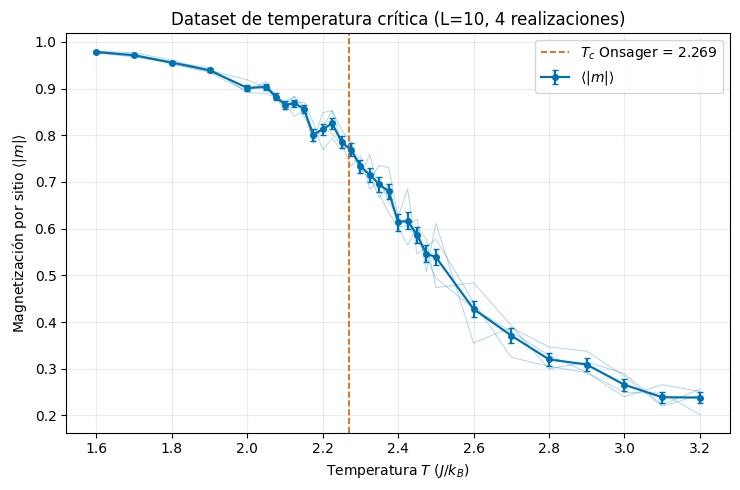

In [27]:
# ============================================================================
# Dataset "temperatura crítica" para L = 10
# Conjunto de TEST para localizar Tc mediante el MLP
#
# Barrido fino por TODAS las temperaturas, incluida la región crítica.
# Las configuraciones NO se utilizan para entrenar el clasificador.
# ============================================================================

# Debe coincidir con el tamaño del dataset de entrenamiento
L_tc = 10

# Número de cadenas Monte Carlo independientes
n_realizaciones_tc = 4

# Configuraciones almacenadas por temperatura y realización
n_config_por_T_tc = 50


# ============================================================================
# Malla de temperaturas
# ============================================================================

temps_criticas = np.unique(
    np.concatenate([
        np.linspace(1.60, 2.00, 5),      # región ordenada
        np.linspace(2.05, 2.50, 19),     # región crítica, paso ≈ 0.025
        np.linspace(2.60, 3.20, 7),      # región desordenada
    ])
)

print("=" * 60)
print(f"GENERACIÓN DEL BARRIDO CRÍTICO PARA L = {L_tc}")
print("=" * 60)

print(f"Número de temperaturas = {len(temps_criticas)}")
print(
    f"Rango de temperaturas = "
    f"[{temps_criticas.min():.3f}, {temps_criticas.max():.3f}]"
)
print(f"Tc de Onsager = {C_ONSAGER:.6f}")


# ============================================================================
# Generación de configuraciones
# ============================================================================

X_tc, T_tc, y_ref_tc, m_tc, r_tc = generar_dataset_ising(
    L=L_tc,
    temperaturas=temps_criticas,
    n_config_por_T=n_config_por_T_tc,
    n_realizaciones=n_realizaciones_tc,
    frontera='periodica',
    n_termalizacion=1500,
    barridos_entre_config=15,

    # No excluir ninguna temperatura:
    # necesitamos precisamente estudiar la región crítica
    margen=0.0,

    simetrizar=True,
    semilla=7,
)


# ============================================================================
# Resumen del dataset generado
# ============================================================================

nT = len(np.unique(T_tc))

print()
print("=" * 60)
print("RESUMEN DEL DATASET DE TEMPERATURA CRÍTICA")
print("=" * 60)

print(
    f"X: {X_tc.shape}   "
    f"dtype={X_tc.dtype}   "
    f"({X_tc.nbytes / 1024:.0f} KiB en memoria)"
)

print(
    f"{n_realizaciones_tc} realizaciones x "
    f"{nT} temperaturas x "
    f"{n_config_por_T_tc} configuraciones "
    f"= {len(T_tc)} configuraciones"
)

print(
    f"Rango de T: "
    f"[{T_tc.min():.3f}, {T_tc.max():.3f}]"
)

print(
    f"Tc de Onsager = "
    f"{C_ONSAGER:.6f}"
)


# ============================================================================
# Guardar archivo
# ============================================================================

ruta_tc = f'temperatura_critica_L{L_tc}.npz'

np.savez_compressed(
    ruta_tc,
    X=X_tc,
    T=T_tc,
    m=m_tc,
    realizacion=r_tc,
    y_ref=y_ref_tc,
    Tc=C_ONSAGER,
    L=np.int64(L_tc),
    frontera='periodica',
)

print()
print(f"Dataset guardado en: {ruta_tc}")


# ============================================================================
# Comprobación física:
# <|m|>(T) por realización y promedio configuracional
# ============================================================================

df_tc = pd.DataFrame({
    'T': T_tc,
    'r': r_tc,
    'm': m_tc
})

# Media y error estándar entre configuraciones
prom = (
    df_tc.groupby('T')['m']
         .agg(['mean', 'sem'])
)


# ============================================================================
# Gráfica
# ============================================================================

fig, ax = plt.subplots(
    figsize=(7.5, 5)
)

# Realizaciones individuales
for _, sub in df_tc.groupby('r'):

    s = (
        sub.groupby('T')['m']
           .mean()
    )

    ax.plot(
        s.index,
        s.values,
        '-',
        color='#0072B2',
        lw=0.7,
        alpha=0.30
    )


# Promedio
ax.errorbar(
    prom.index,
    prom['mean'],
    yerr=prom['sem'],
    fmt='o-',
    color='#0072B2',
    lw=1.6,
    ms=4,
    capsize=2,
    label=r'$\langle |m| \rangle$'
)


# Tc exacta de Onsager
ax.axvline(
    C_ONSAGER,
    color='#D55E00',
    ls='--',
    lw=1.2,
    label=fr'$T_c$ Onsager = {C_ONSAGER:.3f}'
)


# ============================================================================
# Formato
# ============================================================================

ax.set_xlabel(
    r'Temperatura $T$ ($J/k_B$)'
)

ax.set_ylabel(
    r'Magnetización por sitio $\langle |m| \rangle$'
)

ax.set_title(
    f'Dataset de temperatura crítica '
    f'(L={L_tc}, {n_realizaciones_tc} realizaciones)'
)

ax.legend()

ax.grid(alpha=0.25)

fig.tight_layout()

plt.show()

In [30]:
# ============================================================
# BARRIDO DE METROPOLIS CORREGIDO
# Compatible con frontera periódica para L par e impar
#
# L par:
#   actualización checkerboard vectorizada
#
# L impar:
#   actualización secuencial en orden aleatorio
#
# Esto permite trabajar con:
# L = 10, 15, 20, 25, 30
# ============================================================

import numpy as np


def barrido_corregido(self):

    L = self.L

    # ========================================================
    # CASO 1: L PAR
    # Checkerboard vectorizado
    # ========================================================

    if L % 2 == 0:

        # Las máscaras se construyen aquí.
        # Así no dependemos de self.sub_A ni self.sub_B.
        i, j = np.indices((L, L))

        sub_A = ((i + j) % 2 == 0)
        sub_B = ~sub_A

        for subred in (sub_A, sub_B):

            # Suma de vecinos con el método ya definido
            vecinos = self._suma_vecinos()

            # Cambio de energía al invertir cada espín
            dE = (
                2.0
                * self.J
                * self.s
                * vecinos
            )

            # Probabilidad de aceptación.
            # Si dE <= 0, clip -> 0 y exp(0) = 1.
            prob = np.exp(
                -self.beta
                * np.clip(dE, 0.0, None)
            )

            # Decisión aleatoria de aceptación
            voltea = (
                self.rng.random(self.s.shape) < prob
            ) & subred

            self.s[voltea] = -self.s[voltea]


    # ========================================================
    # CASO 2: L IMPAR
    # Metropolis secuencial
    # ========================================================

    else:

        # Un barrido = visitar los L^2 sitios una vez,
        # en orden aleatorio.
        indices = self.rng.permutation(self.N)

        for indice in indices:

            i = indice // L
            j = indice % L

            spin = self.s[i, j]

            # =================================================
            # Frontera periódica
            # =================================================

            if self.frontera == 'periodica':

                suma_vecinos = (
                    self.s[(i - 1) % L, j]
                    + self.s[(i + 1) % L, j]
                    + self.s[i, (j - 1) % L]
                    + self.s[i, (j + 1) % L]
                )

            # =================================================
            # Frontera libre
            # =================================================

            else:

                suma_vecinos = 0

                if i > 0:
                    suma_vecinos += self.s[i - 1, j]

                if i < L - 1:
                    suma_vecinos += self.s[i + 1, j]

                if j > 0:
                    suma_vecinos += self.s[i, j - 1]

                if j < L - 1:
                    suma_vecinos += self.s[i, j + 1]

            # Cambio de energía
            dE = (
                2.0
                * self.J
                * spin
                * suma_vecinos
            )

            # =================================================
            # Regla de aceptación de Metropolis
            # =================================================

            if dE <= 0:

                self.s[i, j] = -spin

            else:

                if self.rng.random() < np.exp(-self.beta * dE):

                    self.s[i, j] = -spin


# ============================================================
# Reemplazar el método de la clase
# ============================================================

IsingMetropolis.barrido = barrido_corregido


print("=" * 60)
print("BARRIDO DE METROPOLIS ACTUALIZADO")
print("=" * 60)

print("L par   -> checkerboard vectorizado")
print("L impar -> Metropolis secuencial aleatorio")

print()
print("Compatible con:")
print("L = 10, 15, 20, 25, 30")

BARRIDO DE METROPOLIS ACTUALIZADO
L par   -> checkerboard vectorizado
L impar -> Metropolis secuencial aleatorio

Compatible con:
L = 10, 15, 20, 25, 30


In [31]:
# ============================================================
# RETO 9
# GENERACIÓN COMPLETA DE DATOS PARA L = 15
# ============================================================

import numpy as np
import time
import os


# ============================================================
# 1. PARÁMETROS GENERALES
# ============================================================

L_actual = 15

C_ONSAGER = 2.0 / np.log(
    1.0 + np.sqrt(2.0)
)

print("=" * 70)
print(f"GENERACIÓN DE DATOS PARA L = {L_actual}")
print("=" * 70)

print(
    f"Tc exacta de Onsager = "
    f"{C_ONSAGER:.8f}"
)

inicio_total = time.time()


# ============================================================
# 2. DATASET DE ENTRENAMIENTO
#
# Temperaturas alejadas de Tc.
# ============================================================

temps_train = np.concatenate([

    # Fase desordenada
    np.linspace(
        3.50,
        2.60,
        5
    ),

    # Fase ordenada
    np.linspace(
        1.90,
        1.20,
        5
    )

])


print()
print("=" * 70)
print("1. DATASET DE ENTRENAMIENTO")
print("=" * 70)

print(
    f"Número de temperaturas = "
    f"{len(temps_train)}"
)

print(
    "Configuraciones esperadas = "
    f"{4 * len(temps_train) * 40}"
)

inicio_train = time.time()


X15, T15, y15, m15, r15 = generar_dataset_ising(

    L=L_actual,

    temperaturas=temps_train,

    n_config_por_T=40,

    n_realizaciones=4,

    frontera='periodica',

    n_termalizacion=1500,

    barridos_entre_config=20,

    # No necesitamos excluir temperaturas:
    # todas están alejadas de Tc.
    margen=0.0,

    simetrizar=True,

    semilla=1015,

    verbose=True
)


tiempo_train = time.time() - inicio_train


# ============================================================
# 3. VERIFICACIONES DEL DATASET DE ENTRENAMIENTO
# ============================================================

assert X15.shape == (1600, 15, 15), (
    f"Forma inesperada: {X15.shape}"
)

assert len(y15) == 1600

assert np.all(
    np.isin(X15, [-1, 1])
), "Hay valores de espín distintos de -1 y +1."

assert (y15 == 0).sum() == 800, (
    "La clase ordenada no tiene 800 configuraciones."
)

assert (y15 == 1).sum() == 800, (
    "La clase desordenada no tiene 800 configuraciones."
)


print()
print("Verificaciones correctas.")

print(
    f"X.shape = {X15.shape}"
)

print(
    f"Clases = {np.bincount(y15)}"
)

print(
    f"|m| medio ordenada = "
    f"{m15[y15 == 0].mean():.4f}"
)

print(
    f"|m| medio desordenada = "
    f"{m15[y15 == 1].mean():.4f}"
)


# ============================================================
# 4. GUARDAR DATASET DE ENTRENAMIENTO
# ============================================================

ruta_train_15 = (
    "ising_dataset_L15.npz"
)

np.savez_compressed(

    ruta_train_15,

    X=X15,

    y=y15,

    T=T15,

    m=m15,

    realizacion=r15,

    Tc=C_ONSAGER,

    L=np.int64(L_actual),

    frontera='periodica'
)


print()
print(
    f"Guardado correctamente:"
    f" {ruta_train_15}"
)

print(
    f"Tiempo entrenamiento = "
    f"{tiempo_train / 60:.2f} min"
)


# ============================================================
# 5. BARRIDO FINO DE TEMPERATURA CRÍTICA
# ============================================================

temps_tc = np.unique(
    np.concatenate([

        # Región ordenada
        np.linspace(
            1.60,
            2.00,
            5
        ),

        # Región crítica
        np.linspace(
            2.05,
            2.50,
            19
        ),

        # Región desordenada
        np.linspace(
            2.60,
            3.20,
            7
        )

    ])
)


print()
print("=" * 70)
print("2. DATASET DE TEMPERATURA CRÍTICA")
print("=" * 70)

print(
    f"Número de temperaturas = "
    f"{len(temps_tc)}"
)

print(
    f"Rango de T = "
    f"[{temps_tc.min():.3f}, "
    f"{temps_tc.max():.3f}]"
)

print(
    "Configuraciones esperadas = "
    f"{4 * len(temps_tc) * 50}"
)


inicio_tc = time.time()


Xtc15, Ttc15, yref15, mtc15, rtc15 = (
    generar_dataset_ising(

        L=L_actual,

        temperaturas=temps_tc,

        n_config_por_T=50,

        n_realizaciones=4,

        frontera='periodica',

        n_termalizacion=1500,

        barridos_entre_config=15,

        # MUY IMPORTANTE:
        # no excluir la región crítica.
        margen=0.0,

        simetrizar=True,

        semilla=2015,

        verbose=True
    )
)


tiempo_tc = time.time() - inicio_tc


# ============================================================
# 6. VERIFICACIONES DEL DATASET CRÍTICO
# ============================================================

assert Xtc15.shape == (6200, 15, 15), (
    f"Forma inesperada: {Xtc15.shape}"
)

assert len(Ttc15) == 6200

assert len(np.unique(Ttc15)) == 31

assert len(np.unique(rtc15)) == 4

assert np.all(
    np.isin(Xtc15, [-1, 1])
), "Hay valores de espín distintos de -1 y +1."


print()
print("Verificaciones correctas.")

print(
    f"X_tc.shape = {Xtc15.shape}"
)

print(
    f"N temperaturas = "
    f"{len(np.unique(Ttc15))}"
)

print(
    f"N realizaciones = "
    f"{len(np.unique(rtc15))}"
)

print(
    f"Rango T = "
    f"[{Ttc15.min():.3f}, "
    f"{Ttc15.max():.3f}]"
)


# ============================================================
# 7. GUARDAR DATASET DE TEMPERATURA CRÍTICA
# ============================================================

ruta_tc_15 = (
    "temperatura_critica_L15.npz"
)

np.savez_compressed(

    ruta_tc_15,

    X=Xtc15,

    T=Ttc15,

    m=mtc15,

    realizacion=rtc15,

    y_ref=yref15,

    Tc=C_ONSAGER,

    L=np.int64(L_actual),

    frontera='periodica'
)


print()
print(
    f"Guardado correctamente:"
    f" {ruta_tc_15}"
)

print(
    f"Tiempo barrido crítico = "
    f"{tiempo_tc / 60:.2f} min"
)


# ============================================================
# 8. VERIFICAR QUE LOS ARCHIVOS EXISTEN
# ============================================================

assert os.path.exists(
    ruta_train_15
)

assert os.path.exists(
    ruta_tc_15
)


# ============================================================
# 9. RESUMEN FINAL
# ============================================================

tiempo_total = (
    time.time() - inicio_total
)


print()
print("=" * 70)
print("L = 15 COMPLETADO CORRECTAMENTE")
print("=" * 70)

print()

print("Archivo de entrenamiento:")
print(
    f"  {ruta_train_15}"
)
print(
    f"  {X15.shape}"
)

print()

print("Archivo de temperatura crítica:")
print(
    f"  {ruta_tc_15}"
)
print(
    f"  {Xtc15.shape}"
)

print()

print(
    f"Tiempo total L=15 = "
    f"{tiempo_total / 60:.2f} minutos"
)

print("=" * 70)

GENERACIÓN DE DATOS PARA L = 15
Tc exacta de Onsager = 2.26918531

1. DATASET DE ENTRENAMIENTO
Número de temperaturas = 10
Configuraciones esperadas = 1600
Generando dataset para L = 15
Sitios por configuración = 225
Temperaturas totales      = 10
Temperaturas utilizadas   = 10
Realizaciones             = 4
Configs por T             = 40
Total esperado           = 1600
L=15 | realización 1/4 lista | 10 temperaturas × 40 configuraciones
L=15 | realización 2/4 lista | 10 temperaturas × 40 configuraciones
L=15 | realización 3/4 lista | 10 temperaturas × 40 configuraciones
L=15 | realización 4/4 lista | 10 temperaturas × 40 configuraciones
-------------------------------------------------------
Dataset L=15 terminado
X.shape = (1600, 15, 15)
y.shape = (1600,)
Clases  = [800 800]
-------------------------------------------------------

Verificaciones correctas.
X.shape = (1600, 15, 15)
Clases = [800 800]
|m| medio ordenada = 0.9760
|m| medio desordenada = 0.2027

Guardado correctamente: isi

In [33]:
# ============================================================
# BARRIDO METROPOLIS DEFINITIVO Y AUTOCONTENIDO
#
# No depende de:
#   self.sub_A
#   self.sub_B
#   self._suma_vecinos()
#
# Compatible con:
#   L = 10, 15, 20, 25, 30
#   frontera periódica y libre
# ============================================================

import numpy as np


def barrido_corregido(self):

    L = self.L
    s = self.s

    # ========================================================
    # CASO 1: L PAR
    # Checkerboard vectorizado
    # ========================================================

    if L % 2 == 0:

        ii, jj = np.indices((L, L))

        sub_A = ((ii + jj) % 2 == 0)
        sub_B = ~sub_A

        for subred in (sub_A, sub_B):

            # ------------------------------------------------
            # Suma de vecinos
            # ------------------------------------------------

            if self.frontera == 'periodica':

                vecinos = (
                    np.roll(s,  1, axis=0)
                    + np.roll(s, -1, axis=0)
                    + np.roll(s,  1, axis=1)
                    + np.roll(s, -1, axis=1)
                )

            else:

                vecinos = np.zeros_like(s, dtype=np.int16)

                # arriba
                vecinos[1:, :] += s[:-1, :]

                # abajo
                vecinos[:-1, :] += s[1:, :]

                # izquierda
                vecinos[:, 1:] += s[:, :-1]

                # derecha
                vecinos[:, :-1] += s[:, 1:]

            # ------------------------------------------------
            # Cambio de energía
            # ------------------------------------------------

            dE = (
                2.0
                * self.J
                * s
                * vecinos
            )

            # ------------------------------------------------
            # Regla de Metropolis
            #
            # dE <= 0 -> aceptación automática
            # dE > 0  -> exp(-beta*dE)
            # ------------------------------------------------

            aleatorios = self.rng.random((L, L))

            aceptar = (
                (dE <= 0)
                |
                (aleatorios < np.exp(-self.beta * np.maximum(dE, 0)))
            )

            # Solo actualizamos la subred correspondiente
            voltear = aceptar & subred

            s[voltear] *= -1


    # ========================================================
    # CASO 2: L IMPAR
    # Metropolis secuencial aleatorio
    # ========================================================

    else:

        # Cada sitio se visita exactamente una vez
        # durante cada barrido.
        indices = self.rng.permutation(L * L)

        for indice in indices:

            i = indice // L
            j = indice % L

            spin = s[i, j]

            # ------------------------------------------------
            # Frontera periódica
            # ------------------------------------------------

            if self.frontera == 'periodica':

                suma_vecinos = (
                    s[(i - 1) % L, j]
                    + s[(i + 1) % L, j]
                    + s[i, (j - 1) % L]
                    + s[i, (j + 1) % L]
                )

            # ------------------------------------------------
            # Frontera libre
            # ------------------------------------------------

            else:

                suma_vecinos = 0

                if i > 0:
                    suma_vecinos += s[i - 1, j]

                if i < L - 1:
                    suma_vecinos += s[i + 1, j]

                if j > 0:
                    suma_vecinos += s[i, j - 1]

                if j < L - 1:
                    suma_vecinos += s[i, j + 1]

            # ------------------------------------------------
            # Cambio de energía
            # ------------------------------------------------

            dE = (
                2.0
                * self.J
                * spin
                * suma_vecinos
            )

            # ------------------------------------------------
            # Regla de Metropolis
            # ------------------------------------------------

            if dE <= 0:

                s[i, j] = -spin

            elif self.rng.random() < np.exp(-self.beta * dE):

                s[i, j] = -spin


# Reemplazamos el método de la clase
IsingMetropolis.barrido = barrido_corregido


print("=" * 65)
print("BARRIDO METROPOLIS DEFINITIVO INSTALADO")
print("=" * 65)
print("No depende de sub_A/sub_B.")
print("No depende de _suma_vecinos().")
print()
print("L par   -> checkerboard vectorizado")
print("L impar -> Metropolis secuencial aleatorio")
print()
print("Preparado para L = 10, 15, 20, 25 y 30.")


BARRIDO METROPOLIS DEFINITIVO INSTALADO
No depende de sub_A/sub_B.
No depende de _suma_vecinos().

L par   -> checkerboard vectorizado
L impar -> Metropolis secuencial aleatorio

Preparado para L = 10, 15, 20, 25 y 30.


In [34]:
# ============================================================
# PRUEBA RÁPIDA DEL BARRIDO DEFINITIVO
# ============================================================

print("=" * 65)
print("PRUEBA DEL ALGORITMO")
print("=" * 65)

for L_test in [15, 20, 25, 30]:

    mc = IsingMetropolis(
        L=L_test,
        T=2.5,
        frontera='periodica',
        semilla=123
    )

    # Solo 20 barridos de prueba
    mc.termalizar(20)

    # Calculamos aquí directamente la magnetización
    # para no depender de otros métodos auxiliares.
    m_test = abs(mc.s.sum()) / (L_test * L_test)

    # Comprobaciones básicas
    assert mc.s.shape == (L_test, L_test)
    assert np.all(np.isin(mc.s, [-1, 1]))

    print(
        f"L={L_test:2d} | "
        f"shape={mc.s.shape} | "
        f"|m|={m_test:.4f} | OK"
    )

print("=" * 65)
print("TODOS LOS TAMAÑOS FUNCIONAN")
print("=" * 65)

PRUEBA DEL ALGORITMO
L=15 | shape=(15, 15) | |m|=0.2444 | OK
L=20 | shape=(20, 20) | |m|=0.6550 | OK
L=25 | shape=(25, 25) | |m|=0.2960 | OK
L=30 | shape=(30, 30) | |m|=0.0067 | OK
TODOS LOS TAMAÑOS FUNCIONAN


In [35]:
# ============================================================
# RETO 9 — GENERACIÓN COMPLETA DE DATOS PARA L = 20
# ============================================================

import numpy as np
import time
import os

# ============================================================
# 1. PARÁMETROS GENERALES
# ============================================================

L_actual = 20

C_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

inicio_total = time.time()

print("=" * 70)
print(f"GENERACIÓN DE DATOS PARA L = {L_actual}")
print("=" * 70)
print(f"Tc exacta de Onsager = {C_ONSAGER:.8f}")


# ============================================================
# 2. TEMPERATURAS DEL DATASET DE ENTRENAMIENTO
# ============================================================

temps_train = np.concatenate([
    np.linspace(3.50, 2.60, 5),   # fase desordenada
    np.linspace(1.90, 1.20, 5),   # fase ordenada
])

print()
print("=" * 70)
print("1. DATASET DE ENTRENAMIENTO")
print("=" * 70)

print(f"Número de temperaturas = {len(temps_train)}")
print(f"Configuraciones esperadas = {4 * len(temps_train) * 40}")


# ============================================================
# 3. GENERAR DATASET DE ENTRENAMIENTO
# ============================================================

inicio_train = time.time()

X20, T20, y20, m20, r20 = generar_dataset_ising(
    L=L_actual,
    temperaturas=temps_train,
    n_config_por_T=40,
    n_realizaciones=4,
    frontera='periodica',
    n_termalizacion=1500,
    barridos_entre_config=20,
    margen=0.0,
    simetrizar=True,
    semilla=1020,
    verbose=True
)

tiempo_train = time.time() - inicio_train


# ============================================================
# 4. VERIFICACIONES DEL DATASET DE ENTRENAMIENTO
# ============================================================

assert X20.shape == (1600, 20, 20), (
    f"Forma inesperada: {X20.shape}"
)

assert len(y20) == 1600

assert np.all(
    np.isin(X20, [-1, 1])
), "Hay valores distintos de -1 y +1."

assert (y20 == 0).sum() == 800, (
    "La clase ordenada no contiene 800 configuraciones."
)

assert (y20 == 1).sum() == 800, (
    "La clase desordenada no contiene 800 configuraciones."
)

print()
print("Verificaciones correctas.")

print(f"X.shape = {X20.shape}")
print(f"y.shape = {y20.shape}")
print(f"Clases = {np.bincount(y20)}")

print(
    f"|m| medio ordenada = "
    f"{m20[y20 == 0].mean():.4f}"
)

print(
    f"|m| medio desordenada = "
    f"{m20[y20 == 1].mean():.4f}"
)


# ============================================================
# 5. GUARDAR DATASET DE ENTRENAMIENTO
# ============================================================

ruta_train_20 = "ising_dataset_L20.npz"

np.savez_compressed(
    ruta_train_20,
    X=X20,
    y=y20,
    T=T20,
    m=m20,
    realizacion=r20,
    Tc=C_ONSAGER,
    L=np.int64(L_actual),
    frontera='periodica'
)

print()
print(f"Guardado correctamente: {ruta_train_20}")
print(f"Tiempo entrenamiento = {tiempo_train / 60:.2f} min")


# ============================================================
# 6. TEMPERATURAS DEL BARRIDO CRÍTICO
# ============================================================

temps_tc = np.unique(
    np.concatenate([
        np.linspace(1.60, 2.00, 5),   # región ordenada
        np.linspace(2.05, 2.50, 19),  # región crítica
        np.linspace(2.60, 3.20, 7),   # región desordenada
    ])
)

print()
print("=" * 70)
print("2. DATASET DE TEMPERATURA CRÍTICA")
print("=" * 70)

print(f"Número de temperaturas = {len(temps_tc)}")
print(
    f"Rango de T = "
    f"[{temps_tc.min():.3f}, {temps_tc.max():.3f}]"
)
print(
    f"Configuraciones esperadas = "
    f"{4 * len(temps_tc) * 50}"
)


# ============================================================
# 7. GENERAR DATASET DE TEMPERATURA CRÍTICA
# ============================================================

inicio_tc = time.time()

Xtc20, Ttc20, yref20, mtc20, rtc20 = generar_dataset_ising(
    L=L_actual,
    temperaturas=temps_tc,
    n_config_por_T=50,
    n_realizaciones=4,
    frontera='periodica',
    n_termalizacion=1500,
    barridos_entre_config=15,
    margen=0.0,           # no se excluye ninguna T
    simetrizar=True,
    semilla=2020,
    verbose=True
)

tiempo_tc = time.time() - inicio_tc


# ============================================================
# 8. VERIFICACIONES DEL DATASET CRÍTICO
# ============================================================

assert Xtc20.shape == (6200, 20, 20), (
    f"Forma inesperada: {Xtc20.shape}"
)

assert len(Ttc20) == 6200

assert len(np.unique(Ttc20)) == 31, (
    "El barrido crítico no contiene 31 temperaturas."
)

assert len(np.unique(rtc20)) == 4, (
    "El dataset no contiene 4 realizaciones."
)

assert np.all(
    np.isin(Xtc20, [-1, 1])
), "Hay valores distintos de -1 y +1."

print()
print("Verificaciones correctas.")

print(f"X_tc.shape = {Xtc20.shape}")
print(f"T_tc.shape = {Ttc20.shape}")
print(f"N temperaturas = {len(np.unique(Ttc20))}")
print(f"N realizaciones = {len(np.unique(rtc20))}")

print(
    f"Rango T = "
    f"[{Ttc20.min():.3f}, {Ttc20.max():.3f}]"
)

print(
    f"Clases de referencia = "
    f"{np.bincount(yref20)}"
)


# ============================================================
# 9. GUARDAR DATASET DE TEMPERATURA CRÍTICA
# ============================================================

ruta_tc_20 = "temperatura_critica_L20.npz"

np.savez_compressed(
    ruta_tc_20,
    X=Xtc20,
    T=Ttc20,
    m=mtc20,
    realizacion=rtc20,
    y_ref=yref20,
    Tc=C_ONSAGER,
    L=np.int64(L_actual),
    frontera='periodica'
)

print()
print(f"Guardado correctamente: {ruta_tc_20}")
print(f"Tiempo barrido crítico = {tiempo_tc / 60:.2f} min")


# ============================================================
# 10. COMPROBAR QUE LOS DOS ARCHIVOS EXISTEN
# ============================================================

assert os.path.exists(ruta_train_20)
assert os.path.exists(ruta_tc_20)


# ============================================================
# 11. RESUMEN FINAL
# ============================================================

tiempo_total = time.time() - inicio_total

print()
print("=" * 70)
print("L = 20 COMPLETADO CORRECTAMENTE")
print("=" * 70)

print()
print("Archivo de entrenamiento:")
print(f"  {ruta_train_20}")
print(f"  X = {X20.shape}")
print(f"  y = {y20.shape}")
print(f"  clases = {np.bincount(y20)}")

print()
print("Archivo de temperatura crítica:")
print(f"  {ruta_tc_20}")
print(f"  X = {Xtc20.shape}")
print(f"  T = {Ttc20.shape}")
print(f"  temperaturas = {len(np.unique(Ttc20))}")
print(f"  realizaciones = {len(np.unique(rtc20))}")

print()
print(f"Tiempo entrenamiento    = {tiempo_train / 60:.2f} min")
print(f"Tiempo barrido crítico  = {tiempo_tc / 60:.2f} min")
print(f"Tiempo total L=20       = {tiempo_total / 60:.2f} min")

print()
print("=" * 70)

GENERACIÓN DE DATOS PARA L = 20
Tc exacta de Onsager = 2.26918531

1. DATASET DE ENTRENAMIENTO
Número de temperaturas = 10
Configuraciones esperadas = 1600
Generando dataset para L = 20
Sitios por configuración = 400
Temperaturas totales      = 10
Temperaturas utilizadas   = 10
Realizaciones             = 4
Configs por T             = 40
Total esperado           = 1600
L=20 | realización 1/4 lista | 10 temperaturas × 40 configuraciones
L=20 | realización 2/4 lista | 10 temperaturas × 40 configuraciones
L=20 | realización 3/4 lista | 10 temperaturas × 40 configuraciones
L=20 | realización 4/4 lista | 10 temperaturas × 40 configuraciones
-------------------------------------------------------
Dataset L=20 terminado
X.shape = (1600, 20, 20)
y.shape = (1600,)
Clases  = [800 800]
-------------------------------------------------------

Verificaciones correctas.
X.shape = (1600, 20, 20)
y.shape = (1600,)
Clases = [800 800]
|m| medio ordenada = 0.9758
|m| medio desordenada = 0.1458

Guardado 

In [36]:
# ============================================================
# RETO 9 — GENERACIÓN COMPLETA DE DATOS PARA L = 25
# ============================================================

import numpy as np
import time
import os

# ============================================================
# 1. PARÁMETROS GENERALES
# ============================================================

L_actual = 25

C_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

inicio_total = time.time()

print("=" * 70)
print(f"GENERACIÓN DE DATOS PARA L = {L_actual}")
print("=" * 70)
print(f"Tc exacta de Onsager = {C_ONSAGER:.8f}")


# ============================================================
# 2. TEMPERATURAS DEL DATASET DE ENTRENAMIENTO
# ============================================================

temps_train = np.concatenate([
    np.linspace(3.50, 2.60, 5),   # fase desordenada
    np.linspace(1.90, 1.20, 5),   # fase ordenada
])

print()
print("=" * 70)
print("1. DATASET DE ENTRENAMIENTO")
print("=" * 70)

print(f"Número de temperaturas = {len(temps_train)}")
print(f"Configuraciones esperadas = {4 * len(temps_train) * 40}")


# ============================================================
# 3. GENERAR DATASET DE ENTRENAMIENTO
# ============================================================

inicio_train = time.time()

X25, T25, y25, m25, r25 = generar_dataset_ising(
    L=L_actual,
    temperaturas=temps_train,
    n_config_por_T=40,
    n_realizaciones=4,
    frontera='periodica',
    n_termalizacion=1500,
    barridos_entre_config=20,
    margen=0.0,
    simetrizar=True,
    semilla=1025,
    verbose=True
)

tiempo_train = time.time() - inicio_train


# ============================================================
# 4. VERIFICACIONES DEL DATASET DE ENTRENAMIENTO
# ============================================================

assert X25.shape == (1600, 25, 25), (
    f"Forma inesperada: {X25.shape}"
)

assert len(y25) == 1600

assert np.all(
    np.isin(X25, [-1, 1])
), "Hay valores distintos de -1 y +1."

assert (y25 == 0).sum() == 800, (
    "La clase ordenada no contiene 800 configuraciones."
)

assert (y25 == 1).sum() == 800, (
    "La clase desordenada no contiene 800 configuraciones."
)

print()
print("Verificaciones correctas.")

print(f"X.shape = {X25.shape}")
print(f"y.shape = {y25.shape}")
print(f"Clases = {np.bincount(y25)}")

print(
    f"|m| medio ordenada = "
    f"{m25[y25 == 0].mean():.4f}"
)

print(
    f"|m| medio desordenada = "
    f"{m25[y25 == 1].mean():.4f}"
)


# ============================================================
# 5. GUARDAR DATASET DE ENTRENAMIENTO
# ============================================================

ruta_train_25 = "ising_dataset_L25.npz"

np.savez_compressed(
    ruta_train_25,
    X=X25,
    y=y25,
    T=T25,
    m=m25,
    realizacion=r25,
    Tc=C_ONSAGER,
    L=np.int64(L_actual),
    frontera='periodica'
)

print()
print(f"Guardado correctamente: {ruta_train_25}")
print(f"Tiempo entrenamiento = {tiempo_train / 60:.2f} min")


# ============================================================
# 6. TEMPERATURAS DEL BARRIDO CRÍTICO
# ============================================================

temps_tc = np.unique(
    np.concatenate([
        np.linspace(1.60, 2.00, 5),   # región ordenada
        np.linspace(2.05, 2.50, 19),  # región crítica
        np.linspace(2.60, 3.20, 7),   # región desordenada
    ])
)

print()
print("=" * 70)
print("2. DATASET DE TEMPERATURA CRÍTICA")
print("=" * 70)

print(f"Número de temperaturas = {len(temps_tc)}")
print(
    f"Rango de T = "
    f"[{temps_tc.min():.3f}, {temps_tc.max():.3f}]"
)
print(
    f"Configuraciones esperadas = "
    f"{4 * len(temps_tc) * 50}"
)


# ============================================================
# 7. GENERAR DATASET DE TEMPERATURA CRÍTICA
# ============================================================

inicio_tc = time.time()

Xtc25, Ttc25, yref25, mtc25, rtc25 = generar_dataset_ising(
    L=L_actual,
    temperaturas=temps_tc,
    n_config_por_T=50,
    n_realizaciones=4,
    frontera='periodica',
    n_termalizacion=1500,
    barridos_entre_config=15,
    margen=0.0,          # incluir TODA la región crítica
    simetrizar=True,
    semilla=2025,
    verbose=True
)

tiempo_tc = time.time() - inicio_tc


# ============================================================
# 8. VERIFICACIONES DEL DATASET CRÍTICO
# ============================================================

assert Xtc25.shape == (6200, 25, 25), (
    f"Forma inesperada: {Xtc25.shape}"
)

assert len(Ttc25) == 6200

assert len(np.unique(Ttc25)) == 31, (
    "El barrido crítico no contiene 31 temperaturas."
)

assert len(np.unique(rtc25)) == 4, (
    "El dataset no contiene 4 realizaciones."
)

assert np.all(
    np.isin(Xtc25, [-1, 1])
), "Hay valores distintos de -1 y +1."

print()
print("Verificaciones correctas.")

print(f"X_tc.shape = {Xtc25.shape}")
print(f"T_tc.shape = {Ttc25.shape}")
print(f"N temperaturas = {len(np.unique(Ttc25))}")
print(f"N realizaciones = {len(np.unique(rtc25))}")

print(
    f"Rango T = "
    f"[{Ttc25.min():.3f}, {Ttc25.max():.3f}]"
)

print(
    f"Clases de referencia = "
    f"{np.bincount(yref25)}"
)


# ============================================================
# 9. GUARDAR DATASET DE TEMPERATURA CRÍTICA
# ============================================================

ruta_tc_25 = "temperatura_critica_L25.npz"

np.savez_compressed(
    ruta_tc_25,
    X=Xtc25,
    T=Ttc25,
    m=mtc25,
    realizacion=rtc25,
    y_ref=yref25,
    Tc=C_ONSAGER,
    L=np.int64(L_actual),
    frontera='periodica'
)

print()
print(f"Guardado correctamente: {ruta_tc_25}")
print(f"Tiempo barrido crítico = {tiempo_tc / 60:.2f} min")


# ============================================================
# 10. COMPROBAR QUE LOS ARCHIVOS EXISTEN
# ============================================================

assert os.path.exists(ruta_train_25)
assert os.path.exists(ruta_tc_25)


# ============================================================
# 11. RESUMEN FINAL
# ============================================================

tiempo_total = time.time() - inicio_total

print()
print("=" * 70)
print("L = 25 COMPLETADO CORRECTAMENTE")
print("=" * 70)

print()
print("Archivo de entrenamiento:")
print(f"  {ruta_train_25}")
print(f"  X = {X25.shape}")
print(f"  y = {y25.shape}")
print(f"  clases = {np.bincount(y25)}")

print()
print("Archivo de temperatura crítica:")
print(f"  {ruta_tc_25}")
print(f"  X = {Xtc25.shape}")
print(f"  T = {Ttc25.shape}")
print(f"  temperaturas = {len(np.unique(Ttc25))}")
print(f"  realizaciones = {len(np.unique(rtc25))}")

print()
print(f"Tiempo entrenamiento    = {tiempo_train / 60:.2f} min")
print(f"Tiempo barrido crítico  = {tiempo_tc / 60:.2f} min")
print(f"Tiempo total L=25       = {tiempo_total / 60:.2f} min")

print()
print("=" * 70)

GENERACIÓN DE DATOS PARA L = 25
Tc exacta de Onsager = 2.26918531

1. DATASET DE ENTRENAMIENTO
Número de temperaturas = 10
Configuraciones esperadas = 1600
Generando dataset para L = 25
Sitios por configuración = 625
Temperaturas totales      = 10
Temperaturas utilizadas   = 10
Realizaciones             = 4
Configs por T             = 40
Total esperado           = 1600
L=25 | realización 1/4 lista | 10 temperaturas × 40 configuraciones
L=25 | realización 2/4 lista | 10 temperaturas × 40 configuraciones
L=25 | realización 3/4 lista | 10 temperaturas × 40 configuraciones
L=25 | realización 4/4 lista | 10 temperaturas × 40 configuraciones
-------------------------------------------------------
Dataset L=25 terminado
X.shape = (1600, 25, 25)
y.shape = (1600,)
Clases  = [800 800]
-------------------------------------------------------

Verificaciones correctas.
X.shape = (1600, 25, 25)
y.shape = (1600,)
Clases = [800 800]
|m| medio ordenada = 0.9756
|m| medio desordenada = 0.1211

Guardado 

In [37]:
# ============================================================
# RETO 9 — GENERACIÓN COMPLETA DE DATOS PARA L = 30
# ============================================================

import numpy as np
import time
import os

# ============================================================
# 1. PARÁMETROS GENERALES
# ============================================================

L_actual = 30

C_ONSAGER = 2.0 / np.log(1.0 + np.sqrt(2.0))

inicio_total = time.time()

print("=" * 70)
print(f"GENERACIÓN DE DATOS PARA L = {L_actual}")
print("=" * 70)
print(f"Tc exacta de Onsager = {C_ONSAGER:.8f}")


# ============================================================
# 2. TEMPERATURAS DEL DATASET DE ENTRENAMIENTO
# ============================================================

temps_train = np.concatenate([
    np.linspace(3.50, 2.60, 5),   # fase desordenada
    np.linspace(1.90, 1.20, 5),   # fase ordenada
])

print()
print("=" * 70)
print("1. DATASET DE ENTRENAMIENTO")
print("=" * 70)

print(f"Número de temperaturas = {len(temps_train)}")
print(f"Configuraciones esperadas = {4 * len(temps_train) * 40}")


# ============================================================
# 3. GENERAR DATASET DE ENTRENAMIENTO
# ============================================================

inicio_train = time.time()

X30, T30, y30, m30, r30 = generar_dataset_ising(
    L=L_actual,
    temperaturas=temps_train,
    n_config_por_T=40,
    n_realizaciones=4,
    frontera='periodica',
    n_termalizacion=1500,
    barridos_entre_config=20,
    margen=0.0,
    simetrizar=True,
    semilla=1030,
    verbose=True
)

tiempo_train = time.time() - inicio_train


# ============================================================
# 4. VERIFICACIONES DEL DATASET DE ENTRENAMIENTO
# ============================================================

assert X30.shape == (1600, 30, 30), (
    f"Forma inesperada: {X30.shape}"
)

assert len(y30) == 1600

assert np.all(
    np.isin(X30, [-1, 1])
), "Hay valores distintos de -1 y +1."

assert (y30 == 0).sum() == 800, (
    "La clase ordenada no contiene 800 configuraciones."
)

assert (y30 == 1).sum() == 800, (
    "La clase desordenada no contiene 800 configuraciones."
)

print()
print("Verificaciones correctas.")
print(f"X.shape = {X30.shape}")
print(f"y.shape = {y30.shape}")
print(f"Clases = {np.bincount(y30)}")

print(
    f"|m| medio ordenada = "
    f"{m30[y30 == 0].mean():.4f}"
)

print(
    f"|m| medio desordenada = "
    f"{m30[y30 == 1].mean():.4f}"
)


# ============================================================
# 5. GUARDAR DATASET DE ENTRENAMIENTO
# ============================================================

ruta_train_30 = "ising_dataset_L30.npz"

np.savez_compressed(
    ruta_train_30,
    X=X30,
    y=y30,
    T=T30,
    m=m30,
    realizacion=r30,
    Tc=C_ONSAGER,
    L=np.int64(L_actual),
    frontera='periodica'
)

print()
print(f"Guardado correctamente: {ruta_train_30}")
print(f"Tiempo entrenamiento = {tiempo_train / 60:.2f} min")


# ============================================================
# 6. TEMPERATURAS DEL BARRIDO CRÍTICO
# ============================================================

temps_tc = np.unique(
    np.concatenate([
        np.linspace(1.60, 2.00, 5),   # región ordenada
        np.linspace(2.05, 2.50, 19),  # región crítica
        np.linspace(2.60, 3.20, 7),   # región desordenada
    ])
)

print()
print("=" * 70)
print("2. DATASET DE TEMPERATURA CRÍTICA")
print("=" * 70)

print(f"Número de temperaturas = {len(temps_tc)}")
print(
    f"Rango de T = "
    f"[{temps_tc.min():.3f}, {temps_tc.max():.3f}]"
)
print(
    f"Configuraciones esperadas = "
    f"{4 * len(temps_tc) * 50}"
)


# ============================================================
# 7. GENERAR DATASET DE TEMPERATURA CRÍTICA
# ============================================================

inicio_tc = time.time()

Xtc30, Ttc30, yref30, mtc30, rtc30 = generar_dataset_ising(
    L=L_actual,
    temperaturas=temps_tc,
    n_config_por_T=50,
    n_realizaciones=4,
    frontera='periodica',
    n_termalizacion=1500,
    barridos_entre_config=15,
    margen=0.0,          # incluir toda la zona crítica
    simetrizar=True,
    semilla=2030,
    verbose=True
)

tiempo_tc = time.time() - inicio_tc


# ============================================================
# 8. VERIFICACIONES DEL DATASET CRÍTICO
# ============================================================

assert Xtc30.shape == (6200, 30, 30), (
    f"Forma inesperada: {Xtc30.shape}"
)

assert len(Ttc30) == 6200

assert len(np.unique(Ttc30)) == 31, (
    "El barrido crítico no contiene 31 temperaturas."
)

assert len(np.unique(rtc30)) == 4, (
    "El dataset no contiene 4 realizaciones."
)

assert np.all(
    np.isin(Xtc30, [-1, 1])
), "Hay valores distintos de -1 y +1."

print()
print("Verificaciones correctas.")
print(f"X_tc.shape = {Xtc30.shape}")
print(f"T_tc.shape = {Ttc30.shape}")
print(f"N temperaturas = {len(np.unique(Ttc30))}")
print(f"N realizaciones = {len(np.unique(rtc30))}")

print(
    f"Rango T = "
    f"[{Ttc30.min():.3f}, {Ttc30.max():.3f}]"
)

print(
    f"Clases de referencia = "
    f"{np.bincount(yref30)}"
)


# ============================================================
# 9. GUARDAR DATASET DE TEMPERATURA CRÍTICA
# ============================================================

ruta_tc_30 = "temperatura_critica_L30.npz"

np.savez_compressed(
    ruta_tc_30,
    X=Xtc30,
    T=Ttc30,
    m=mtc30,
    realizacion=rtc30,
    y_ref=yref30,
    Tc=C_ONSAGER,
    L=np.int64(L_actual),
    frontera='periodica'
)

print()
print(f"Guardado correctamente: {ruta_tc_30}")
print(f"Tiempo barrido crítico = {tiempo_tc / 60:.2f} min")


# ============================================================
# 10. COMPROBAR QUE LOS DOS ARCHIVOS EXISTEN
# ============================================================

assert os.path.exists(ruta_train_30)
assert os.path.exists(ruta_tc_30)


# ============================================================
# 11. RESUMEN FINAL
# ============================================================

tiempo_total = time.time() - inicio_total

print()
print("=" * 70)
print("L = 30 COMPLETADO CORRECTAMENTE")
print("=" * 70)

print()
print("Archivo de entrenamiento:")
print(f"  {ruta_train_30}")
print(f"  X = {X30.shape}")
print(f"  y = {y30.shape}")
print(f"  clases = {np.bincount(y30)}")

print()
print("Archivo de temperatura crítica:")
print(f"  {ruta_tc_30}")
print(f"  X = {Xtc30.shape}")
print(f"  T = {Ttc30.shape}")
print(f"  temperaturas = {len(np.unique(Ttc30))}")
print(f"  realizaciones = {len(np.unique(rtc30))}")

print()
print(f"Tiempo entrenamiento    = {tiempo_train / 60:.2f} min")
print(f"Tiempo barrido crítico  = {tiempo_tc / 60:.2f} min")
print(f"Tiempo total L=30       = {tiempo_total / 60:.2f} min")

print()
print("=" * 70)
print("GENERACIÓN DE DATOS FINALIZADA")
print("=" * 70)

GENERACIÓN DE DATOS PARA L = 30
Tc exacta de Onsager = 2.26918531

1. DATASET DE ENTRENAMIENTO
Número de temperaturas = 10
Configuraciones esperadas = 1600
Generando dataset para L = 30
Sitios por configuración = 900
Temperaturas totales      = 10
Temperaturas utilizadas   = 10
Realizaciones             = 4
Configs por T             = 40
Total esperado           = 1600
L=30 | realización 1/4 lista | 10 temperaturas × 40 configuraciones
L=30 | realización 2/4 lista | 10 temperaturas × 40 configuraciones
L=30 | realización 3/4 lista | 10 temperaturas × 40 configuraciones
L=30 | realización 4/4 lista | 10 temperaturas × 40 configuraciones
-------------------------------------------------------
Dataset L=30 terminado
X.shape = (1600, 30, 30)
y.shape = (1600,)
Clases  = [800 800]
-------------------------------------------------------

Verificaciones correctas.
X.shape = (1600, 30, 30)
y.shape = (1600,)
Clases = [800 800]
|m| medio ordenada = 0.9754
|m| medio desordenada = 0.0984

Guardado 